# 240907 Revision 8 soil experiment, before rewetting (Griess assay)
- Analysis: Kiseok Lee
- Date: 9/11/24, experiment and measurement of 240901 - 240905 (5 days each)
- Testing Question: N dynamics before rewetting

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append('./custom_functions')
import pandas as pd
import numpy as np
import griess as gr
import bmgdata as bd
import glob
import denitfit as dn
import pickle
import matplotlib.pyplot as plt
import importlib

# figure size and font size
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (20, 12),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
pylab.rcParams.update(params)

## Make output directory



In [2]:
newpath = r'20241103'
if not os.path.exists(newpath):
    os.makedirs(newpath)

## 1. Standard curves with griess assay

## 1.1. 2M KCl based standard curves (not from 10/6/21 stock)

### (1) Using bubble removal using well scan (well quadrant bubble correction)

20241103/standard_metadata.csv
None
20241103/20241103_Ik_NO2_standard_540.CSV
20241103/20241103_Ik_NO2_standard_900.CSV
20241103/20241103_Ik_NO2NO3_standard_540.CSV
20241103/20241103_Ik_NO2NO3_standard_900.CSV
returns true for elements more than 1.5 interquartile ranges above the upper quartile
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []
returns true for elements more than 1.5 interquartile ranges above the upper quartile
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


 (From sklearn LinearRegression) Manual calculation of p-value. Here we use sklearn LinearRegression package
   Coefficients  Standard Errors  t values  P-Values
0        0.0057           0.0128    0.4481    0.6565
1        2.2526           0.0477   47.2666    0.0000
2       -0.1070           0.0251   -4.2686    0.0001


 (From statsmodel package) Coefficients are a bit differe

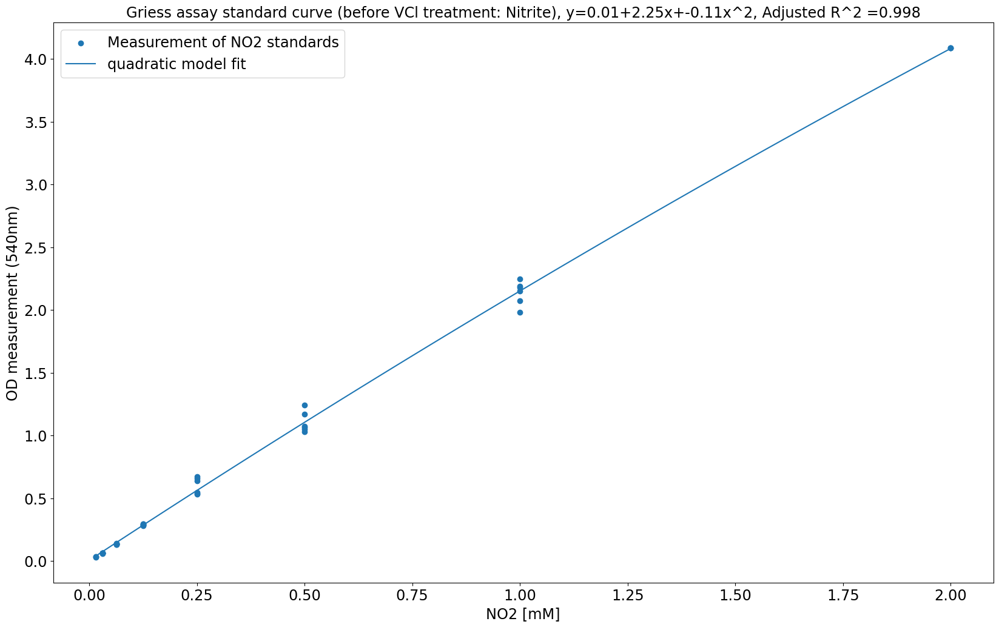

In [4]:
#fit griess assay model using standard curves
std_meta_fn = "20241103/standard_metadata.csv"
print(std_meta_fn)
std_no2_fn = None
print(std_no2_fn)
std_no2_540_fn = glob.glob("20241103/20241103_Ik_NO2_standard_540.CSV")[0]
print(std_no2_540_fn)
std_no2_900_fn = glob.glob("20241103/20241103_Ik_NO2_standard_900.CSV")[0]
print(std_no2_900_fn)

std_no2no3_fn = None
std_no2no3_540_fn = glob.glob("20241103/20241103_Ik_NO2NO3_standard_540.CSV")[0]
print(std_no2no3_540_fn)
std_no2no3_900_fn = glob.glob("20241103/20241103_Ik_NO2NO3_standard_900.CSV")[0]
print(std_no2no3_900_fn)

# plot standard curve
gr.plot_griess_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig('20241103/plots/standard_kcl_standard_curve_with_bubble_removal.png')

# fitted parameters
fit_list = gr.fit_griess(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
[[no2_blank,no2no3_blank], g_fit, v_fit, no3_fit] = fit_list


Load standard curve

### (2) After VCl treatment (nitrate reduction to nitrite)

[np.float64(0.003969117403543998), np.float64(1.2215902948267165), np.float64(-0.10284133401532919)]
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


 (From sklearn LinearRegression) Manual calculation of p-value. Here we use sklearn LinearRegression package
   Coefficients  Standard Errors  t values  P-Values
0        0.0040           0.0076    0.5190    0.6052
1        1.2216           0.0268   45.6202    0.0000
2       -0.1028           0.0130   -7.8878    0.0000


 (From statsmodel package) Coefficients are a bit different from the sklearn LinearRegression package
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.998
Model:                            OLS   Adj. R-squared (uncentered):              0.998
Method:                 Least Squares   F-statistic:                          2.034e+04
Da

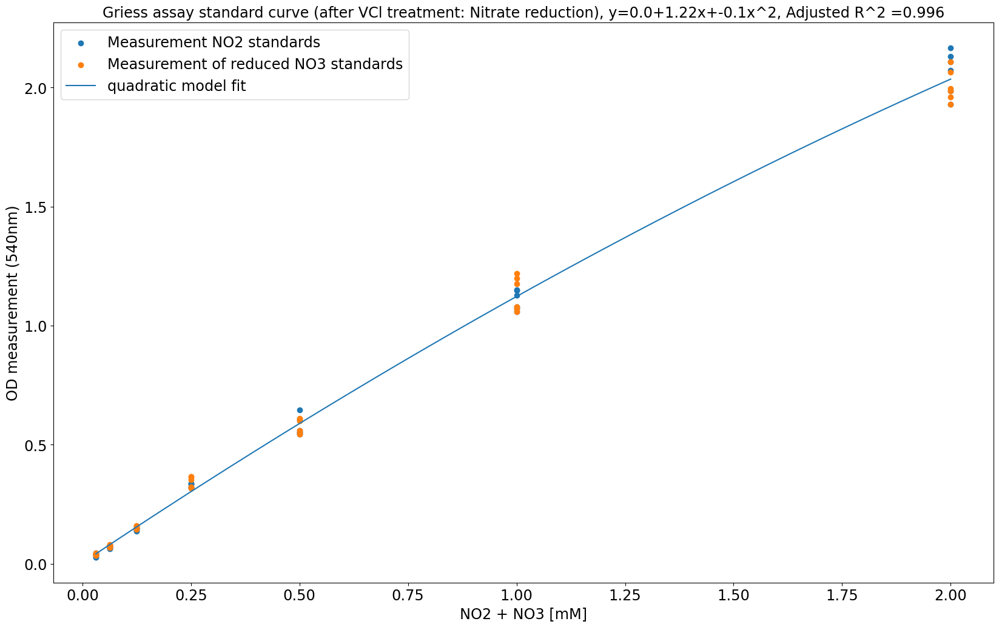

In [5]:
plt.cla()
print(v_fit)

gr.plot_vcl_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig('20241103/plots/standard_kcl_vcl_treated_standard_curve.png')

### (3) Checking the known concentration and the predicted concentration of the NO2-, NO3- mixed standards

returns true for elements more than 1.5 interquartile ranges above the upper quartile
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


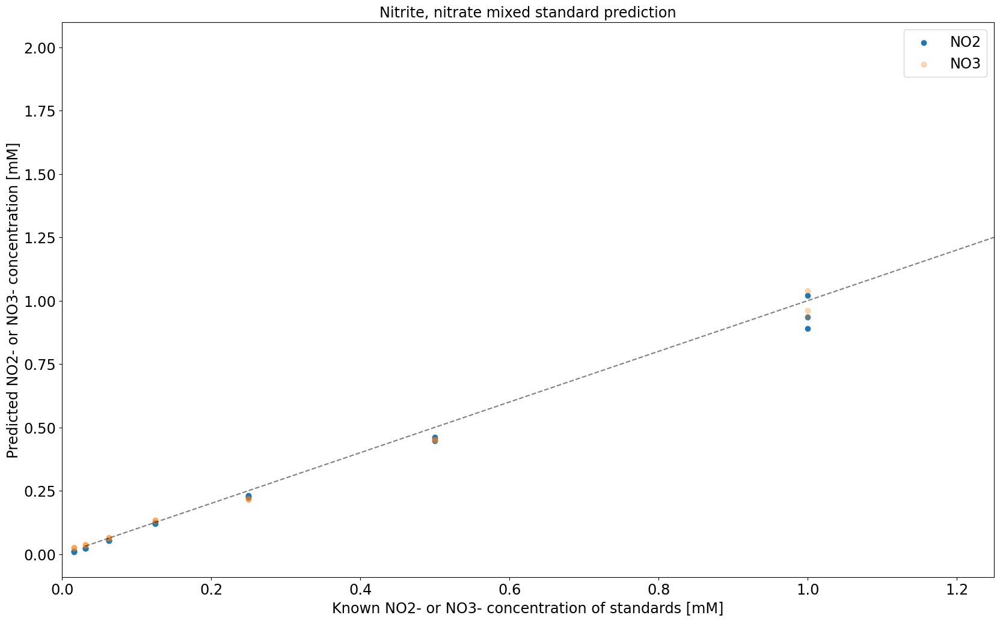

In [6]:
# check mixed conditions prediction
importlib.reload(dn)
gr.plot_mixed_standard_predict(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig('20241103/plots/standard_kcl_mixed_prediction.png')

### (4) Only use nitrate standards for fitting the curve

[np.float64(-0.00349335154826913), np.float64(1.3744829460444734), np.float64(-0.18437232780810833)]
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


 (From sklearn LinearRegression) Manual calculation of p-value. Here we use sklearn LinearRegression package
   Coefficients  Standard Errors  t values  P-Values
0       -0.0035           0.0100   -0.3488    0.7311
1        1.3745           0.0351   39.1960    0.0000
2       -0.1844           0.0171  -10.7983    0.0000


 (From statsmodel package) Coefficients are a bit different from the sklearn LinearRegression package
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          1.256e+04
Da

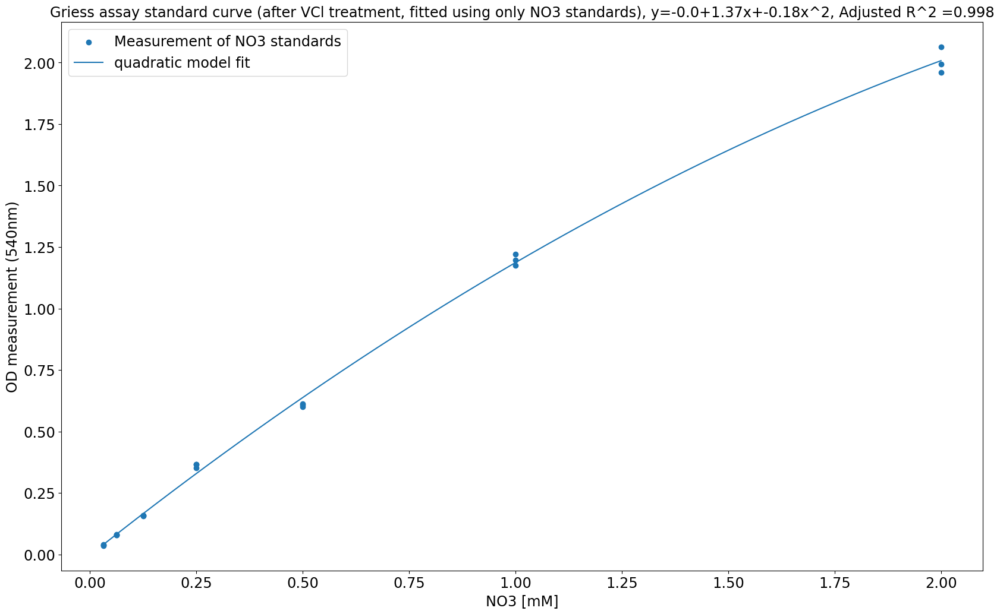

In [7]:
print(no3_fit)

gr.plot_no3_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig('20241103/plots/standard_kcl_vcl_treated_standard_curve_only_using_NO3_standards.png')

returns true for elements more than 1.5 interquartile ranges above the upper quartile
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


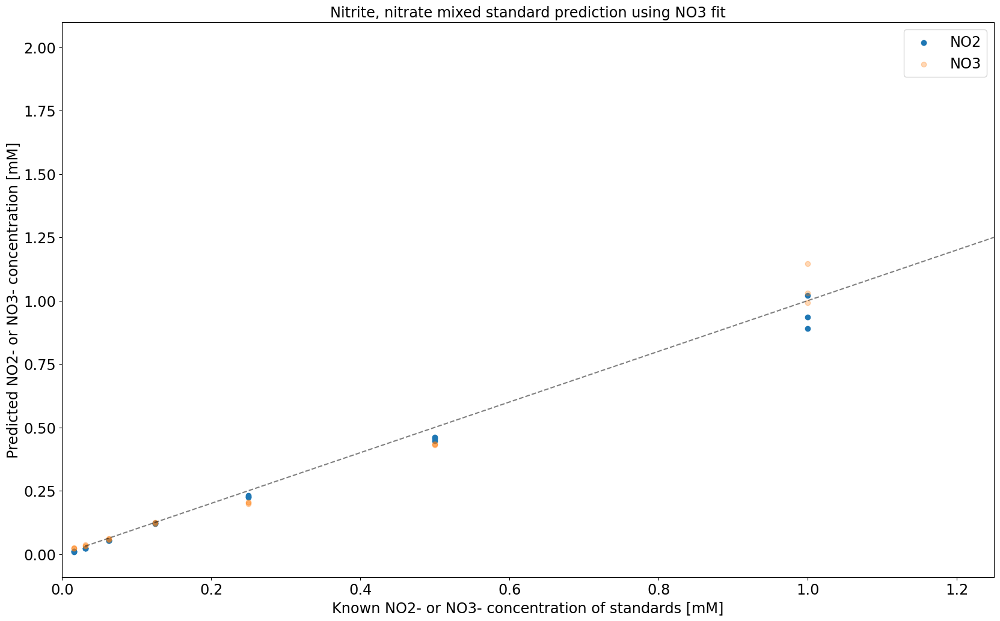

In [8]:
gr.plot_mixed_standard_predict_with_no3_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig('20241103/plots/standard_kcl_mixed_prediction_using_no3_fit.png')

## Make sure that the wellscan is removing all outliers from our data.

In [53]:
## generate all sample names
#l_soil = ["AW_plate1_2", "Starke3","Oxbow3","Washington2"]
l_soil = ["RBW12","RBW34"]
l_timepoint = ['T' + str(i) for i in range(0,10) ]

RBW12_T0
./240907_Griess/sample_metadata_RBW12_T0.csv
None
./240907_Griess\RBW12_T0_20240907_Absorbance_KL_NO2_SCAN_540.csv
./240907_Griess\RBW12_T0_20240907_Absorbance_KL_NO2_SCAN_900.csv
None
./240907_Griess\RBW12_T0_20240908_Absorbance_KL_NO2NO3_SCAN_540.csv
./240907_Griess\RBW12_T0_20240908_Absorbance_KL_NO2NO3_SCAN_900.csv
Check wellscan for outlier removal in NO2
returns true for elements more than 1 interquartile ranges above the upper quartile


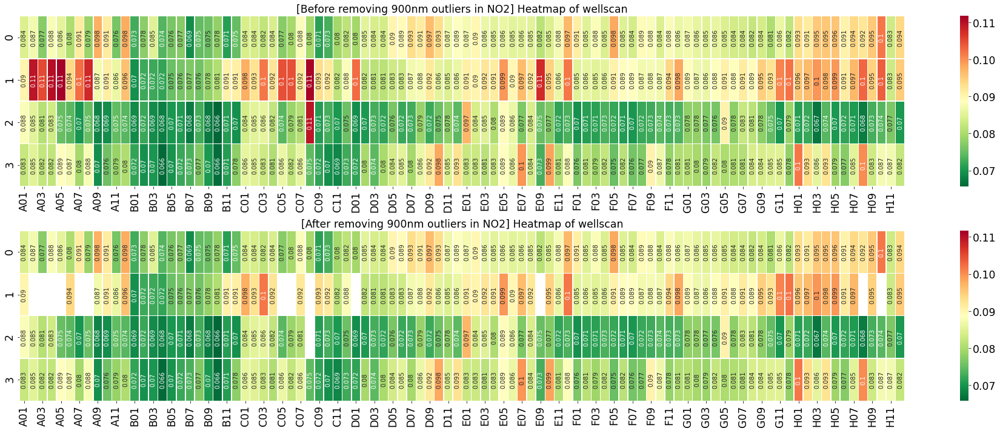

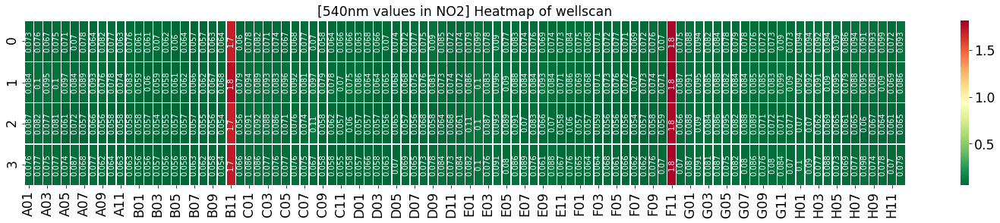

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


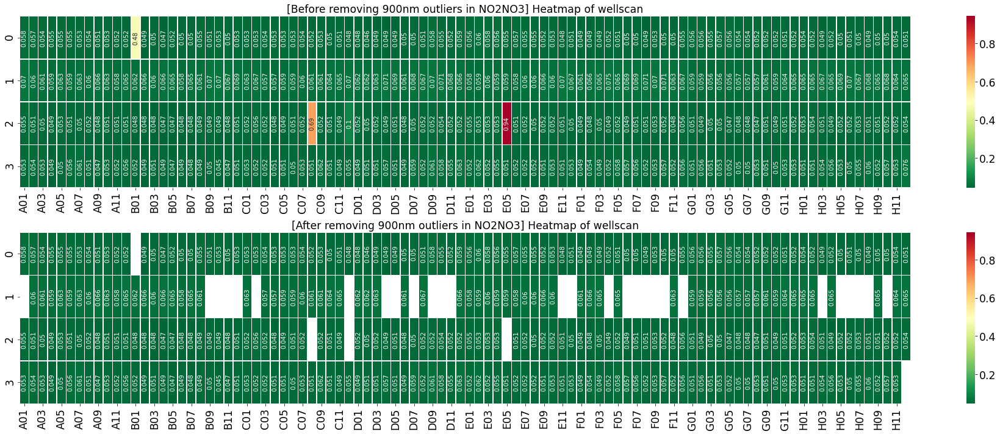

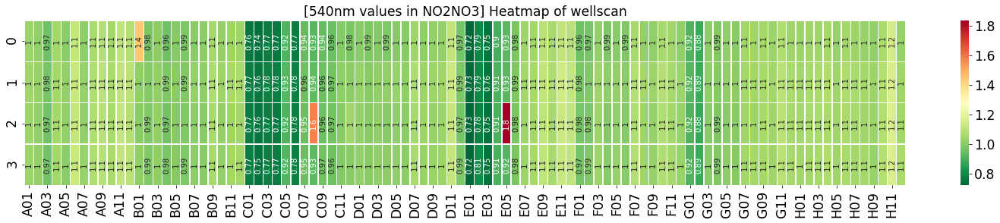

./240907_Griess/sample_metadata_RBW12_T0.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.08020
A02    0.07680
A03    0.07490
A04    0.07680
A05    0.07130
        ...   
H08    0.09090
H09    0.08085
H10    0.07770
H11    0.06975
H12    0.08245
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    1.03900
A02    1.02145
A03    0.96935
A04    1.05230
A05    1.01895
        ...   
H08    1.04450
H09    1.03610
H10    1.08710
H11    1.16615
H12    1.04540
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.017761
A02    0.016247
A03    0.015402
A04    0.016247
A05    0.013800
         ...   
H08    0.022526
H09    0.018051
H10    0.016648
H11    0.013110
H12    0.018763
Name: NO2_mM, Length: 96, dtype: float64
A01    0.795400
A02    0.779398
A03    0.732079
A04    0.807

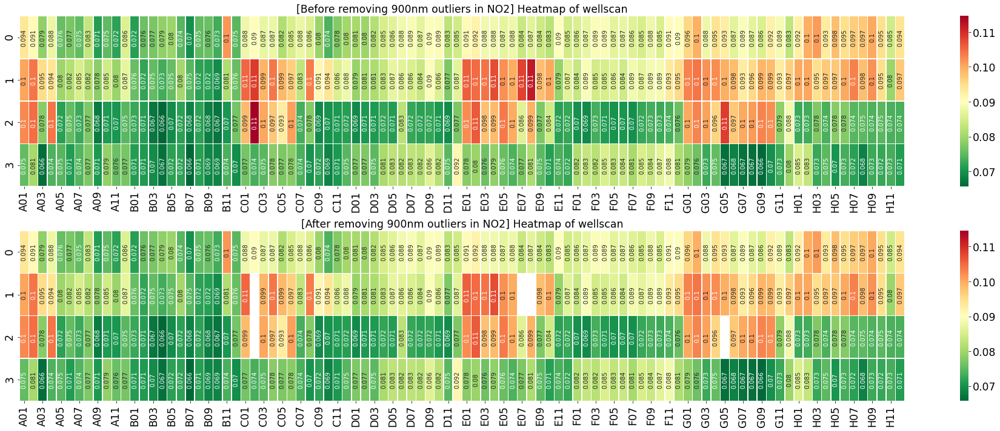

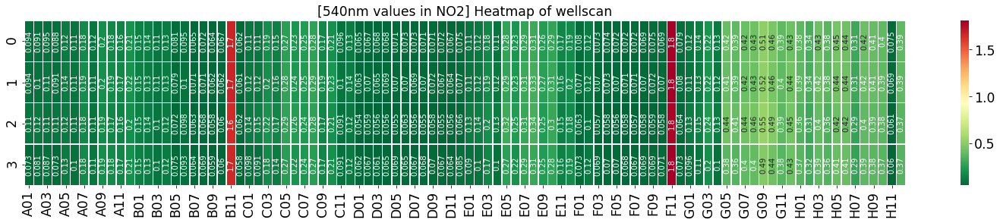

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


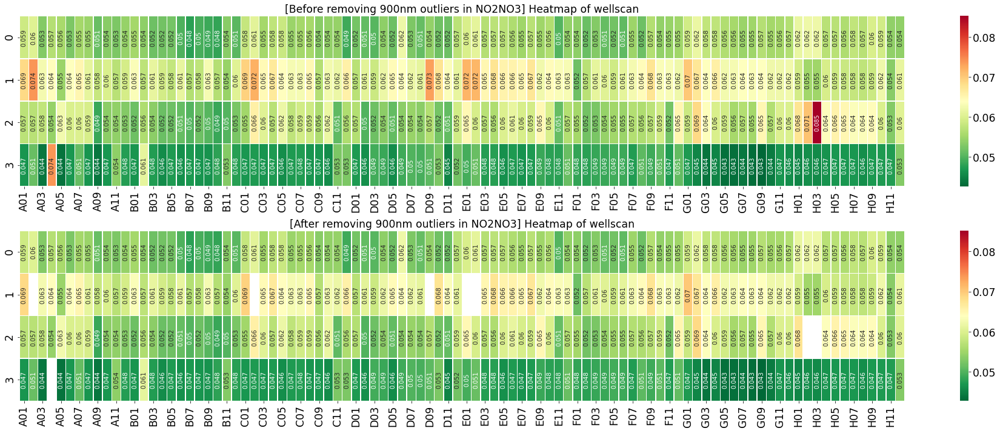

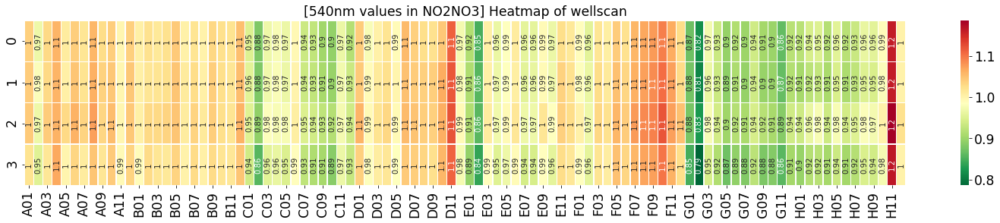

./240907_Griess/sample_metadata_RBW12_T1.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.09390
A02    0.09590
A03    0.10055
A04    0.08925
A05    0.12570
        ...   
H08    0.40610
H09    0.39590
H10    0.38700
H11    0.06480
H12    0.38295
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    1.04035
A02    0.96870
A03    1.03055
A04    1.06070
A05    1.00765
        ...   
H08    0.95705
H09    0.95145
H10    0.98600
H11    1.16460
H12    1.00295
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.023863
A02    0.024754
A03    0.026826
A04    0.021791
A05    0.038042
         ...   
H08    0.164066
H09    0.159450
H10    0.155424
H11    0.010907
H12    0.153592
Name: NO2_mM, Length: 96, dtype: float64
A01    0.796632
A02    0.731490
A03    0.787691
A04    0.815

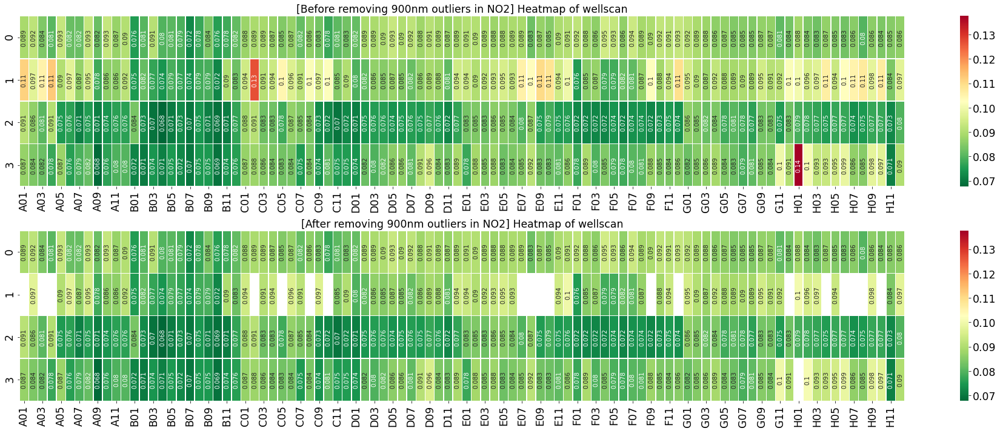

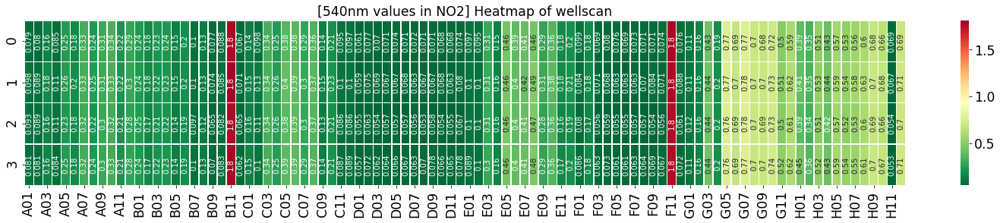

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


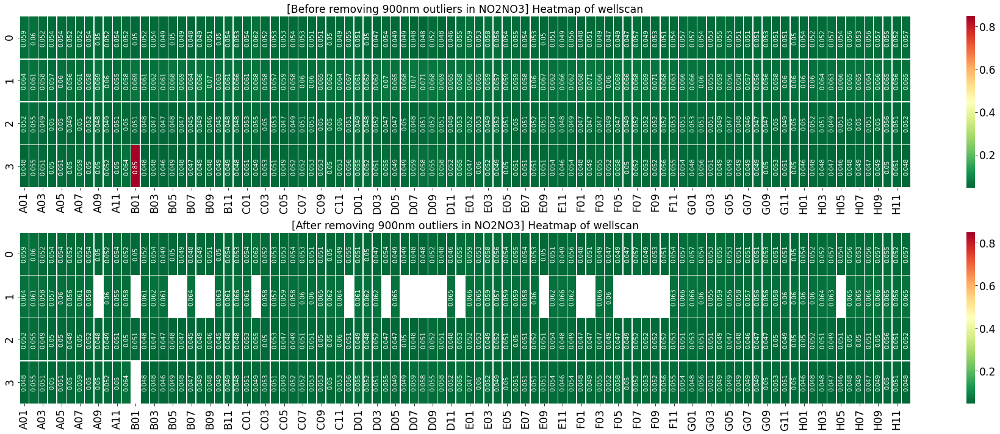

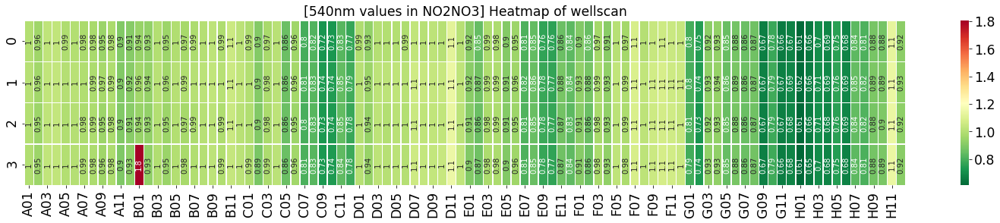

./240907_Griess/sample_metadata_RBW12_T2.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.08130
A02    0.08480
A03    0.15650
A04    0.08460
A05    0.24865
        ...   
H08    0.59980
H09    0.69695
H10    0.65700
H11    0.06070
H12    0.70380
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    1.00060
A02    0.95570
A03    1.03025
A04    1.03375
A05    0.99685
        ...   
H08    0.81335
H09    0.88195
H10    0.88840
H11    1.14335
H12    0.92260
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.018251
A02    0.019809
A03    0.051797
A04    0.019720
A05    0.093079
         ...   
H08    0.252196
H09    0.296739
H10    0.278394
H11    0.009906
H12    0.299888
Name: NO2_mM, Length: 96, dtype: float64
A01    0.760428
A02    0.719727
A03    0.787418
A04    0.790

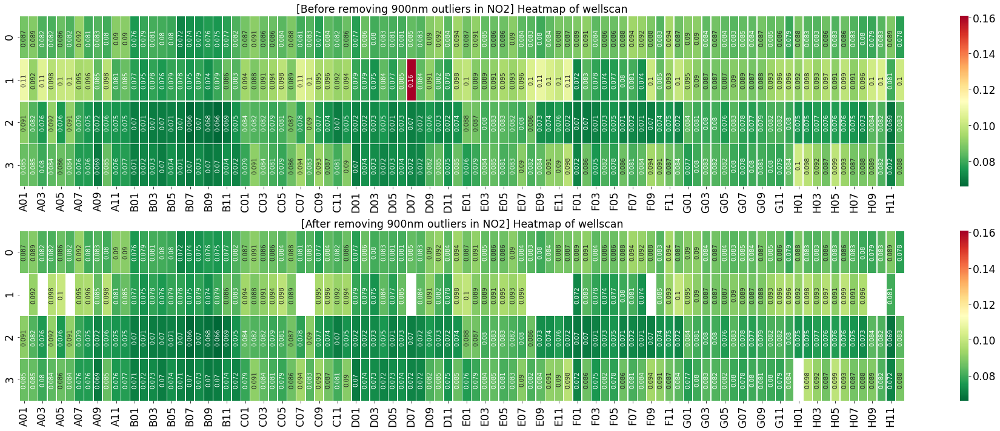

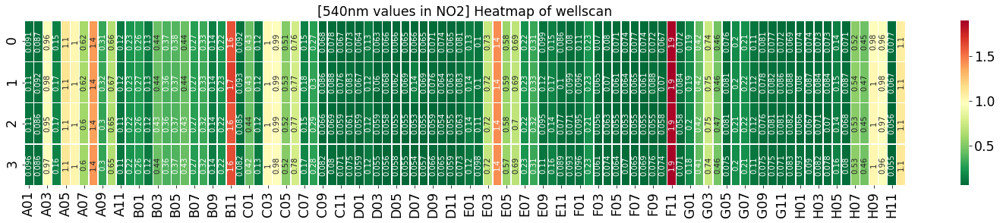

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


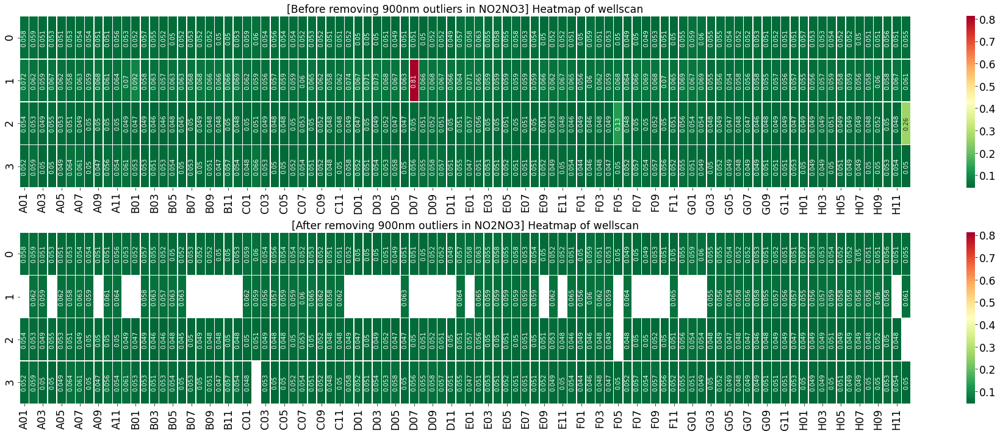

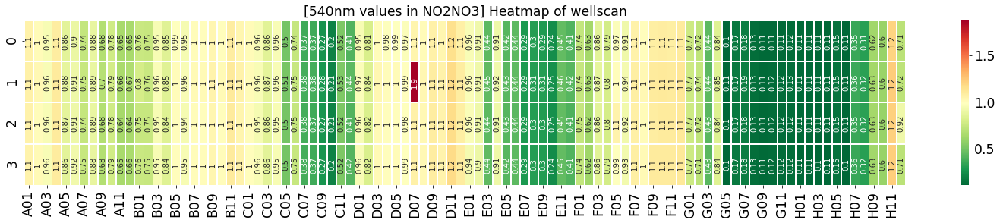

./240907_Griess/sample_metadata_RBW12_T3.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.09600
A02    0.08660
A03    0.95960
A04    0.16380
A05    1.11525
        ...   
H08    0.45625
H09    1.01550
H10    0.96120
H11    0.06175
H12    1.10060
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    1.06030
A02    1.01935
A03    0.95685
A04    1.09630
A05    0.86815
        ...   
H08    0.31715
H09    0.62870
H10    0.59675
H11    1.22040
H12    0.71230
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.024798
A02    0.020611
A03    0.418333
A04    0.055060
A05    0.491221
         ...   
H08    0.186798
H09    0.444437
H10    0.419079
H11    0.009906
H12    0.484334
Name: NO2_mM, Length: 96, dtype: float64
A01    0.814864
A02    0.777485
A03    0.720767
A04    0.847

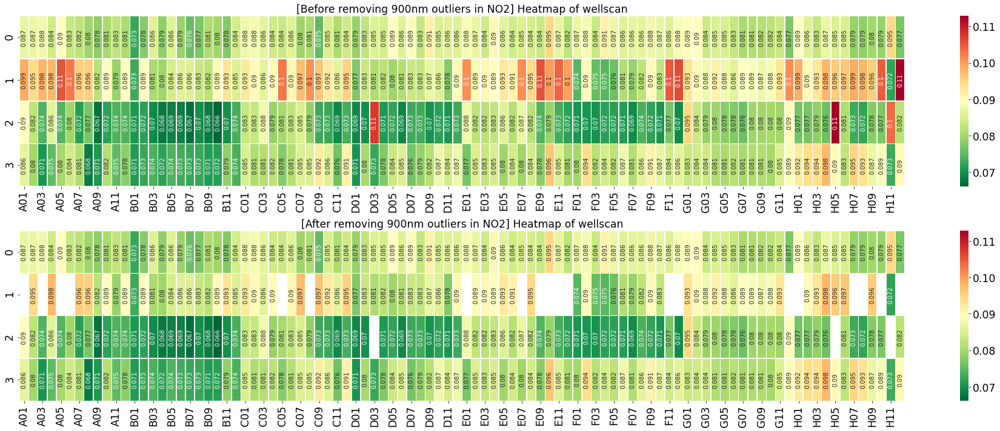

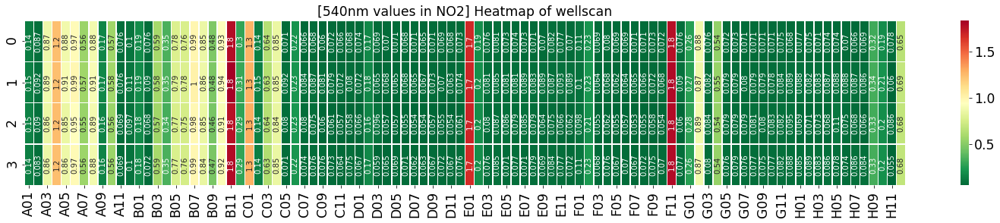

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


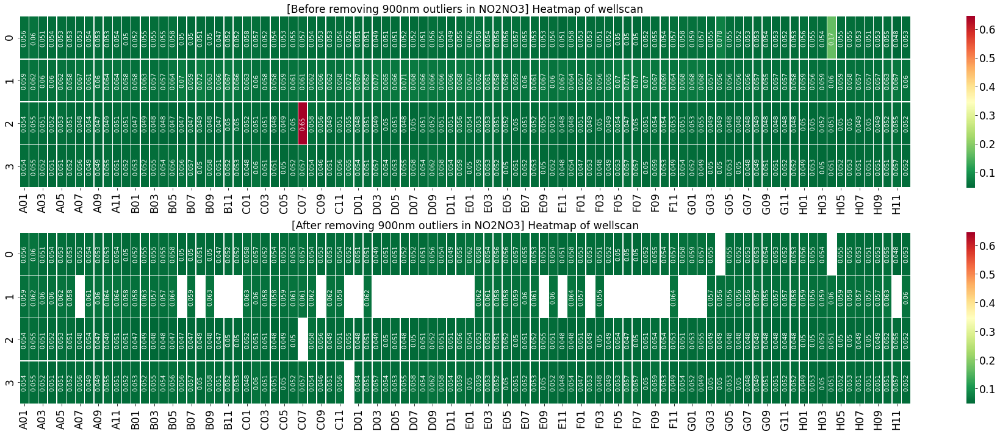

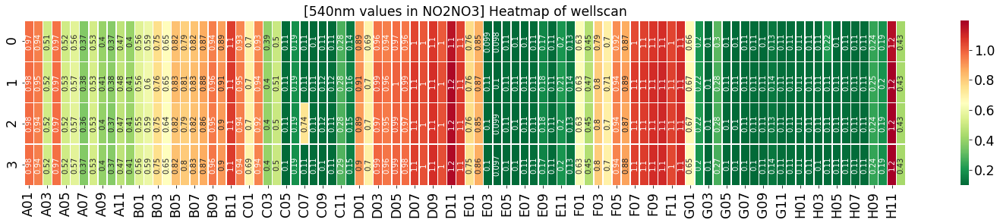

./240907_Griess/sample_metadata_RBW12_T4.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.14220
A02    0.08875
A03    0.86120
A04    1.24000
A05    0.86470
        ...   
H08    0.06900
H09    0.33180
H10    0.19580
H11    0.05960
H12    0.67890
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.97670
A02    0.94440
A03    0.51810
A04    0.97135
A05    0.51920
        ...   
H08    0.10825
H09    0.24365
H10    0.19160
H11    1.19270
H12    0.43055
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.045408
A02    0.021569
A03    0.372575
A04    0.550100
A05    0.374198
         ...   
H08    0.012776
H09    0.130496
H10    0.069379
H11    0.009906
H12    0.288445
Name: NO2_mM, Length: 96, dtype: float64
A01    0.738738
A02    0.709516
A03    0.333233
A04    0.733

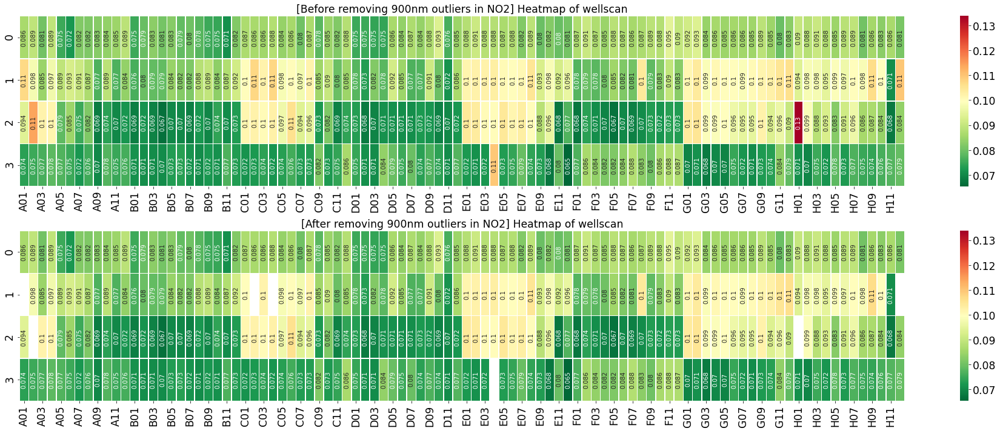

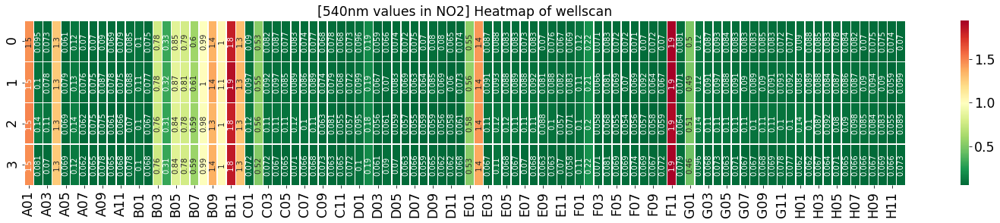

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


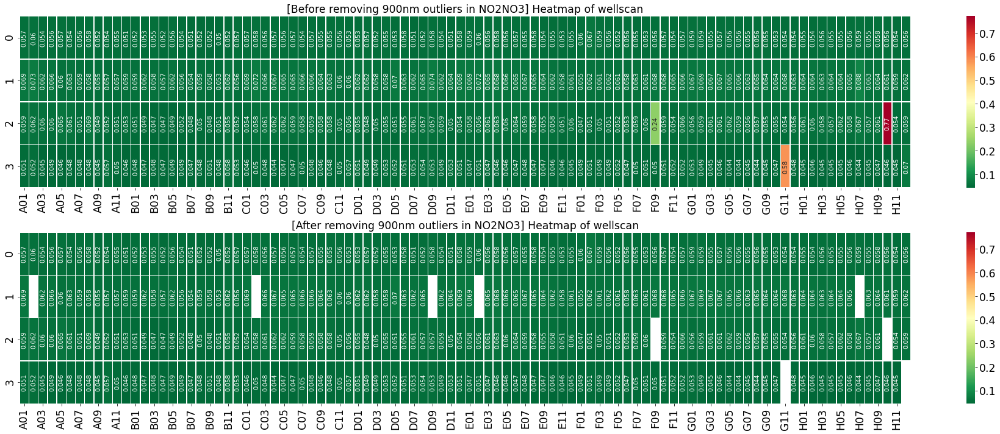

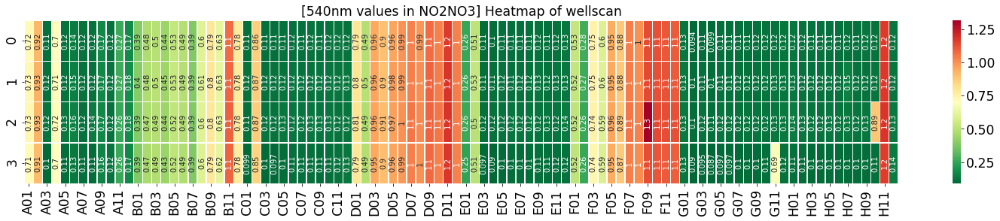

./240907_Griess/sample_metadata_RBW12_T5.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    1.46050
A02    0.09520
A03    0.07570
A04    1.26975
A05    0.06880
        ...   
H08    0.07755
H09    0.07945
H10    0.07935
H11    0.06255
H12    0.07310
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.72395
A02    0.92180
A03    0.11425
A04    0.70585
A05    0.11775
        ...   
H08    0.11745
H09    0.12065
H10    0.12000
H11    1.17065
H12    0.12360
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.655200
A02    0.024442
A03    0.015758
A04    0.564203
A05    0.012687
         ...   
H08    0.016581
H09    0.017427
H10    0.017383
H11    0.009906
H12    0.014601
Name: NO2_mM, Length: 96, dtype: float64
A01    0.512810
A02    0.689132
A03    0.000000
A04    0.496

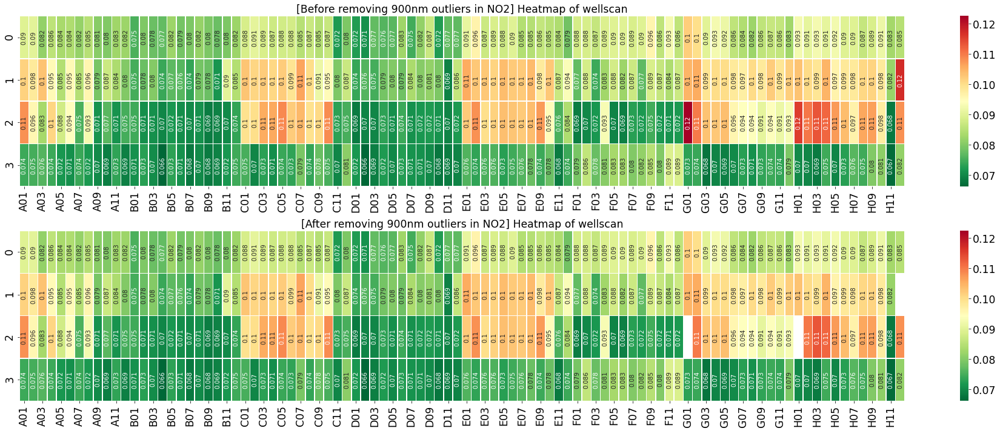

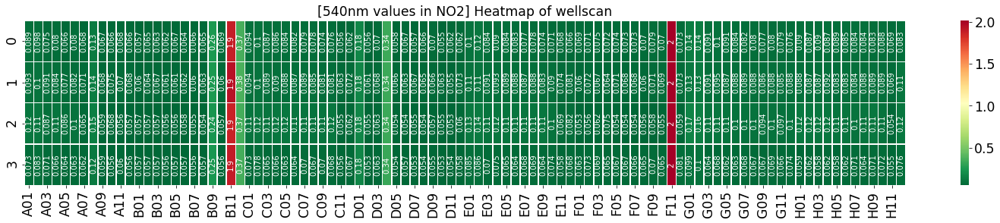

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


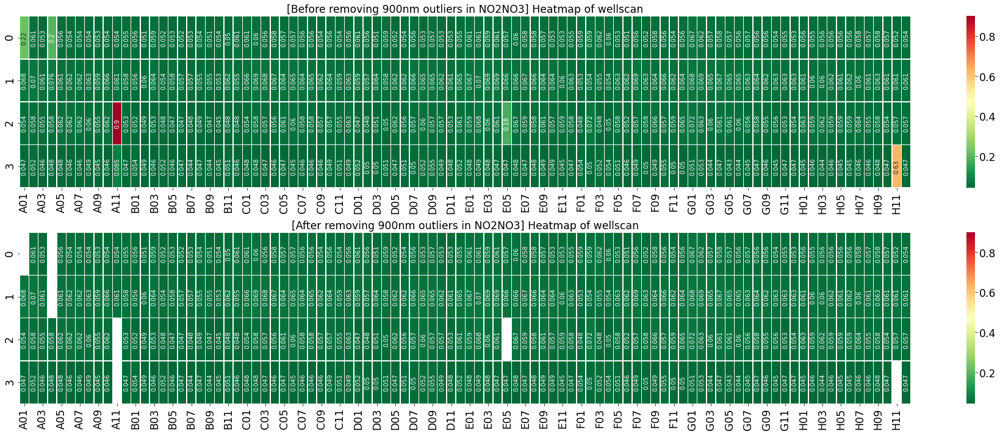

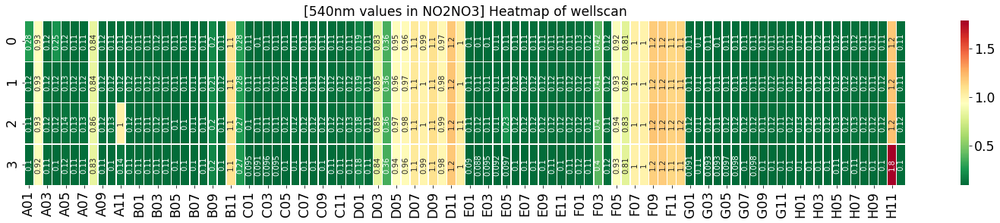

./240907_Griess/sample_metadata_RBW12_T6.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.09070
A02    0.10100
A03    0.08090
A04    0.08225
A05    0.07165
        ...   
H08    0.08570
H09    0.08570
H10    0.08865
H11    0.06180
H12    0.08310
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.11380
A02    0.92900
A03    0.11925
A04    0.11155
A05    0.12305
        ...   
H08    0.11490
H09    0.11300
H10    0.11495
H11    1.20010
H12    0.11300
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.022437
A02    0.027027
A03    0.018073
A04    0.018674
A05    0.013955
         ...   
H08    0.020210
H09    0.020210
H10    0.021524
H11    0.009906
H12    0.019052
Name: NO2_mM, Length: 96, dtype: float64
A01    0.000000
A02    0.695620
A03    0.000000
A04    0.000

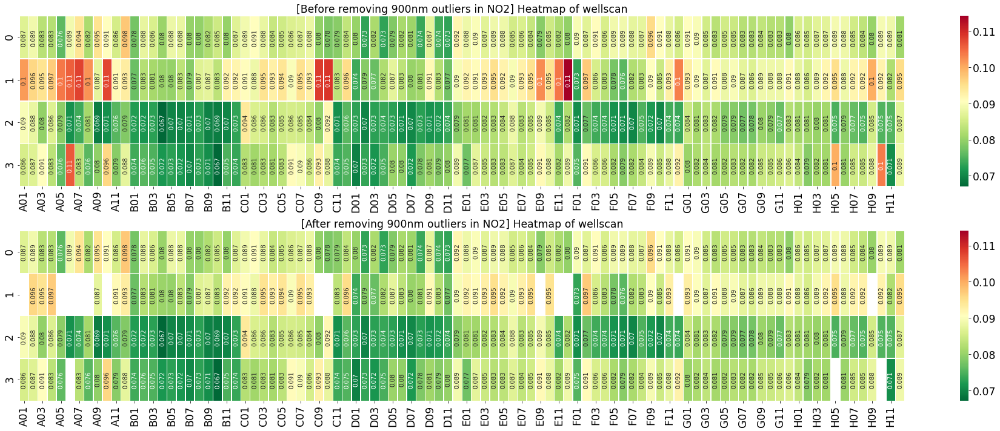

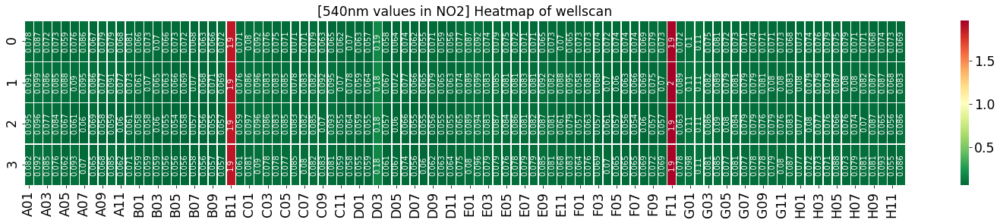

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


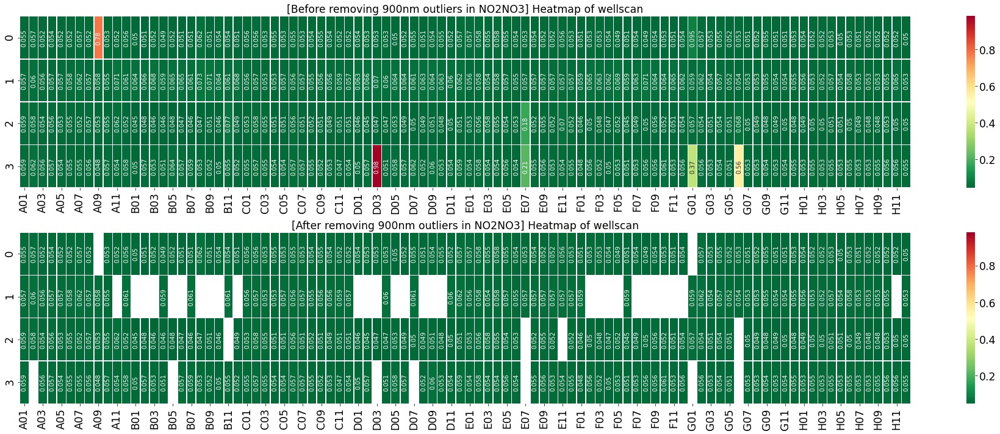

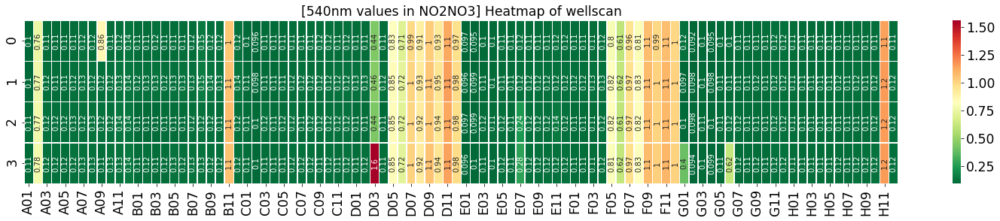

./240907_Griess/sample_metadata_RBW12_T7.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.08240
A02    0.09385
A03    0.08075
A04    0.07990
A05    0.06160
        ...   
H08    0.07575
H09    0.08090
H10    0.07430
H11    0.06170
H12    0.08470
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.10555
A02    0.76750
A03    0.12040
A04    0.11475
A05    0.11465
        ...   
H08    0.11535
H09    0.11170
H10    0.11700
H11    1.16020
H12    0.11725
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.018741
A02    0.023841
A03    0.018006
A04    0.017628
A05    0.009906
         ...   
H08    0.015780
H09    0.018073
H10    0.015135
H11    0.009906
H12    0.019765
Name: NO2_mM, Length: 96, dtype: float64
A01    0.00000
A02    0.55130
A03    0.00000
A04    0.00000


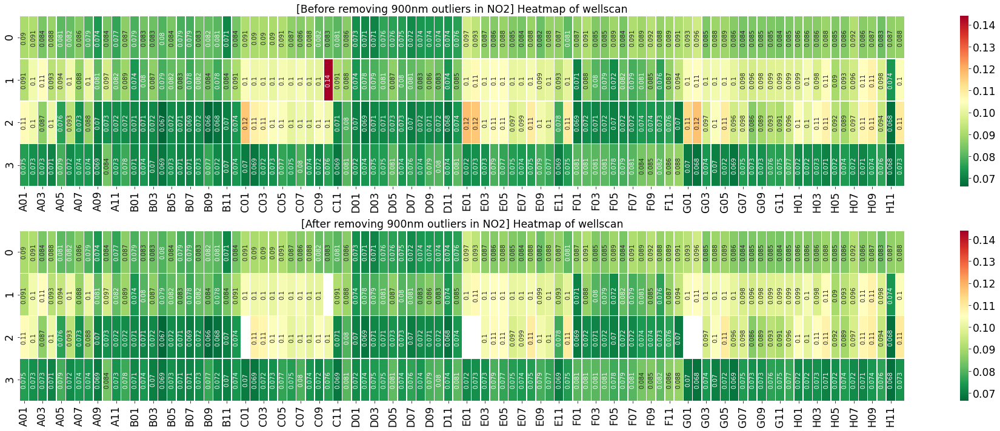

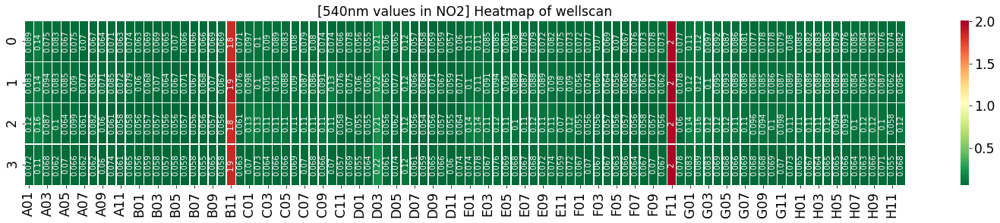

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


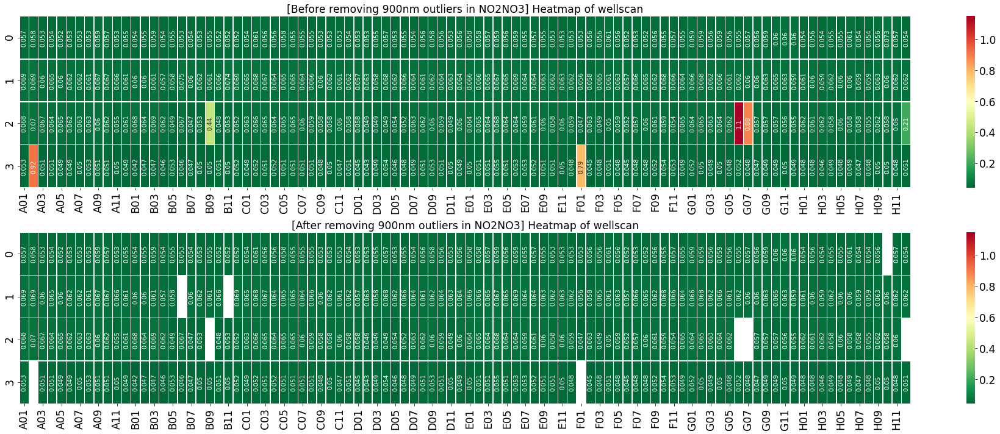

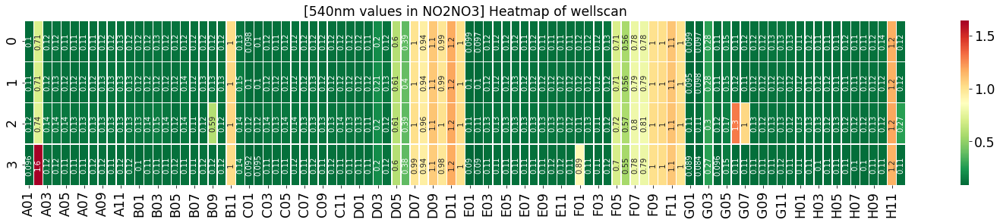

./240907_Griess/sample_metadata_RBW12_T8.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.08560
A02    0.13695
A03    0.08120
A04    0.08310
A05    0.06825
        ...   
H08    0.08780
H09    0.08835
H10    0.08170
H11    0.05980
H12    0.08840
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.10295
A02    0.71330
A03    0.12100
A04    0.12290
A05    0.11610
        ...   
H08    0.11355
H09    0.11905
H10    0.11830
H11    1.16815
H12    0.11700
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.020166
A02    0.043064
A03    0.018206
A04    0.019052
A05    0.012442
         ...   
H08    0.021145
H09    0.021390
H10    0.018429
H11    0.009906
H12    0.021413
Name: NO2_mM, Length: 96, dtype: float64
A01    0.000000
A02    0.503425
A03    0.000000
A04    0.000

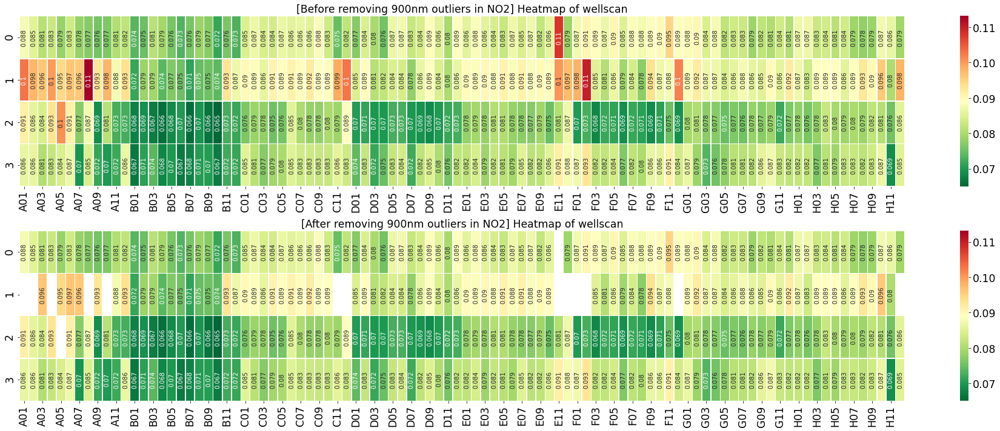

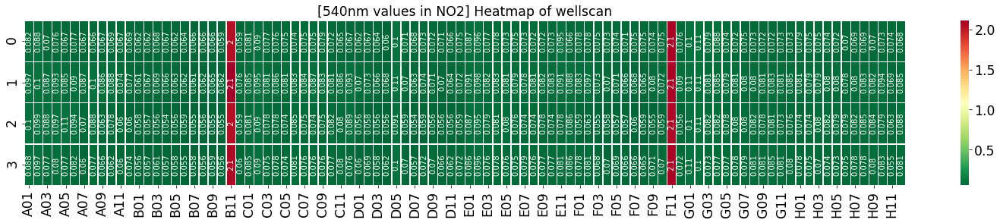

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


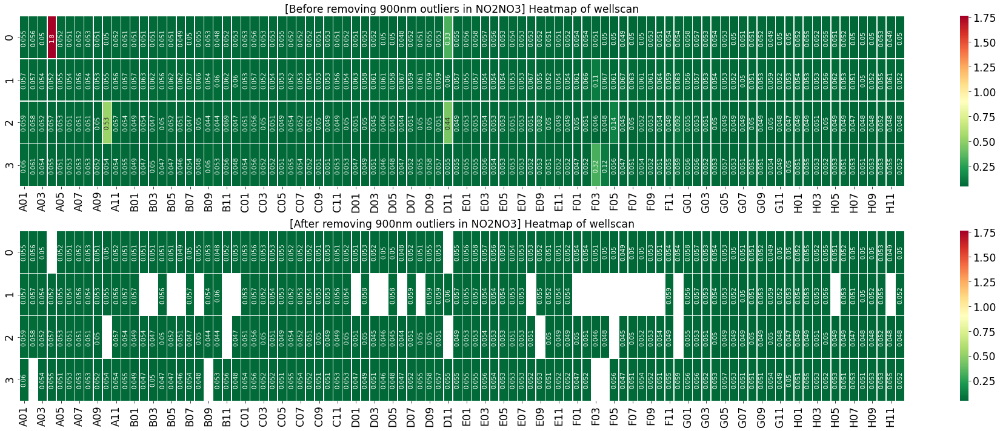

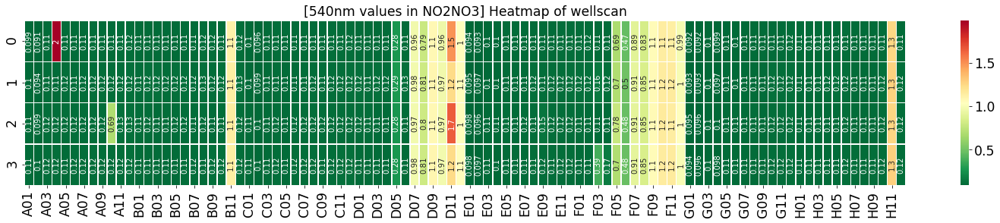

./240907_Griess/sample_metadata_RBW12_T9.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.08850
A02    0.09650
A03    0.08225
A04    0.08020
A05    0.07710
        ...   
H08    0.08075
H09    0.08060
H10    0.08070
H11    0.06565
H12    0.08140
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.10410
A02    0.09430
A03    0.11540
A04    0.11640
A05    0.11480
        ...   
H08    0.11055
H09    0.11090
H10    0.11765
H11    1.26540
H12    0.11660
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.021457
A02    0.025021
A03    0.018674
A04    0.017761
A05    0.016381
         ...   
H08    0.018006
H09    0.017939
H10    0.017984
H11    0.011285
H12    0.018295
Name: NO2_mM, Length: 96, dtype: float64
A01    0.000000
A02    0.000000
A03    0.000000
A04    0.000

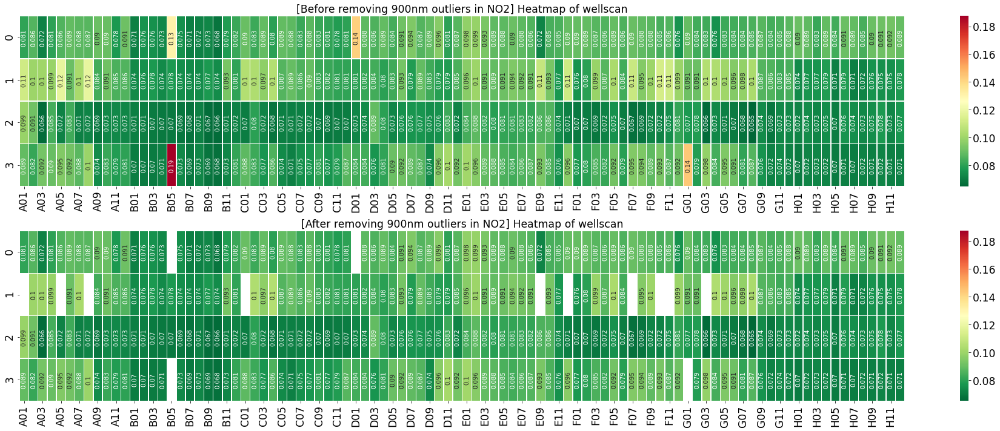

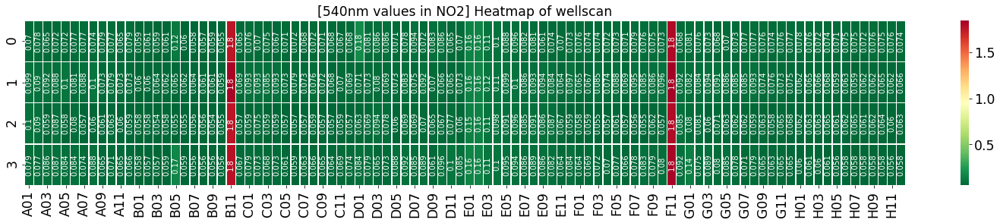

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


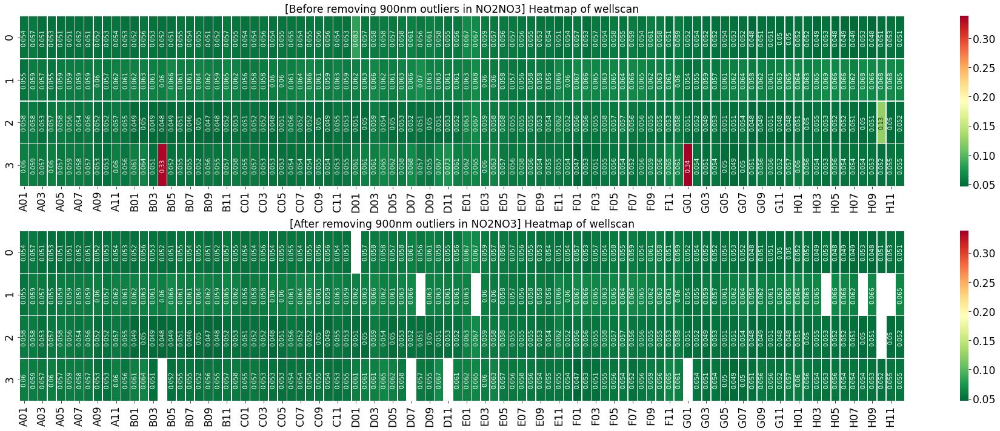

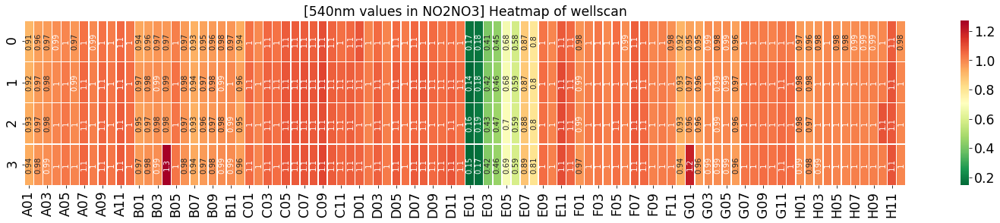

./240907_Griess/sample_metadata_RBW34_T0.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.07920
A02    0.08380
A03    0.07510
A04    0.08685
A05    0.07170
        ...   
H08    0.06170
H09    0.06215
H10    0.06445
H11    0.06115
H12    0.06440
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.92955
A02    0.96895
A03    0.98380
A04    1.00005
A05    1.02460
        ...   
H08    1.00660
H09    1.01035
H10    1.00580
H11    1.08540
H12    0.99995
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.017316
A02    0.019364
A03    0.015491
A04    0.020722
A05    0.013978
         ...   
H08    0.009906
H09    0.009906
H10    0.010752
H11    0.009906
H12    0.010729
Name: NO2_mM, Length: 96, dtype: float64
A01    0.696116
A02    0.731717
A03    0.745175
A04    0.759

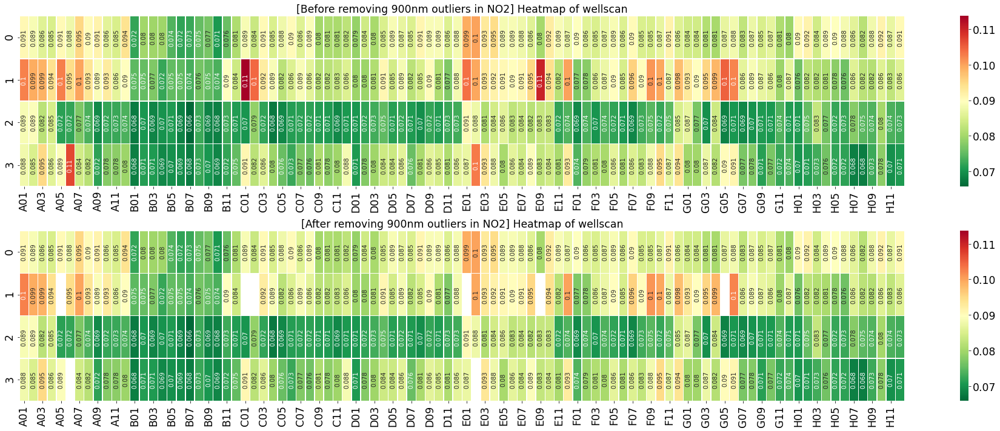

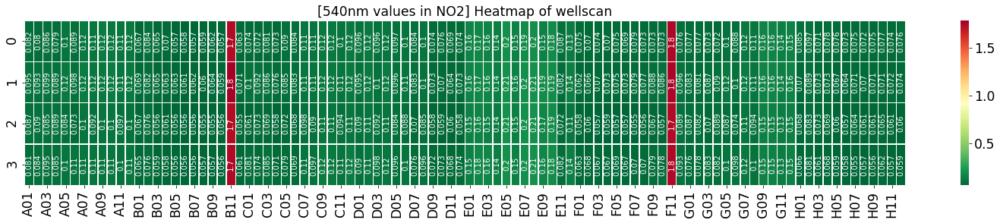

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


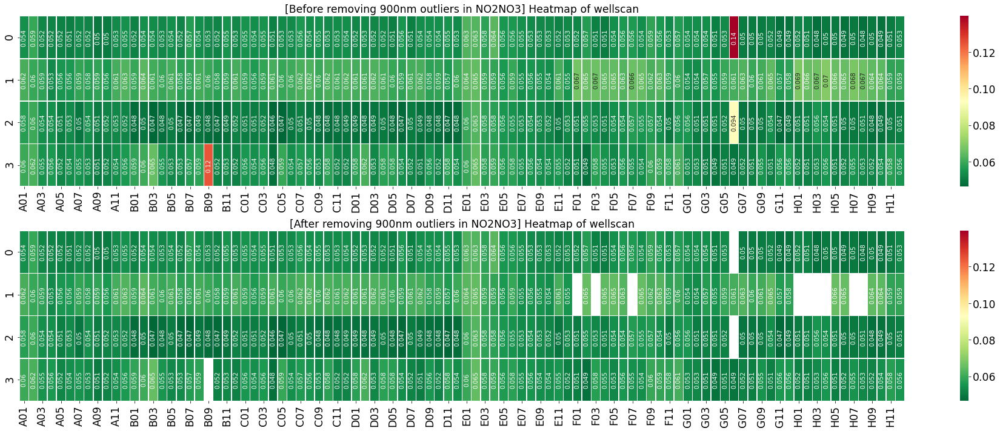

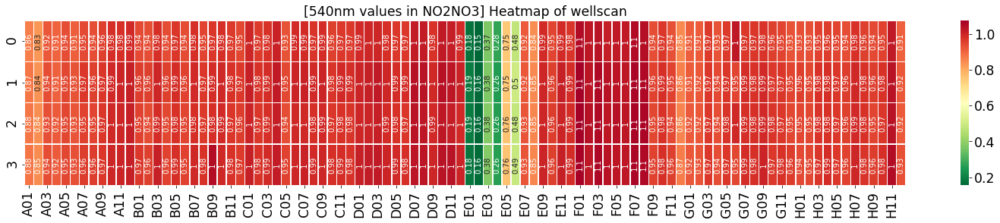

./240907_Griess/sample_metadata_RBW34_T1.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.08455
A02    0.08730
A03    0.09050
A04    0.08685
A05    0.10300
        ...   
H08    0.06585
H09    0.06585
H10    0.06820
H11    0.06635
H12    0.06705
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.87515
A02    0.84060
A03    0.93570
A04    0.91415
A05    0.94815
        ...   
H08    0.97790
H09    0.95700
H10    0.97620
H11    1.03725
H12    0.92070
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.019698
A02    0.020923
A03    0.022348
A04    0.020722
A05    0.027918
         ...   
H08    0.011374
H09    0.011374
H10    0.012420
H11    0.011597
H12    0.011908
Name: NO2_mM, Length: 96, dtype: float64
A01    0.647216
A02    0.616310
A03    0.701663
A04    0.682

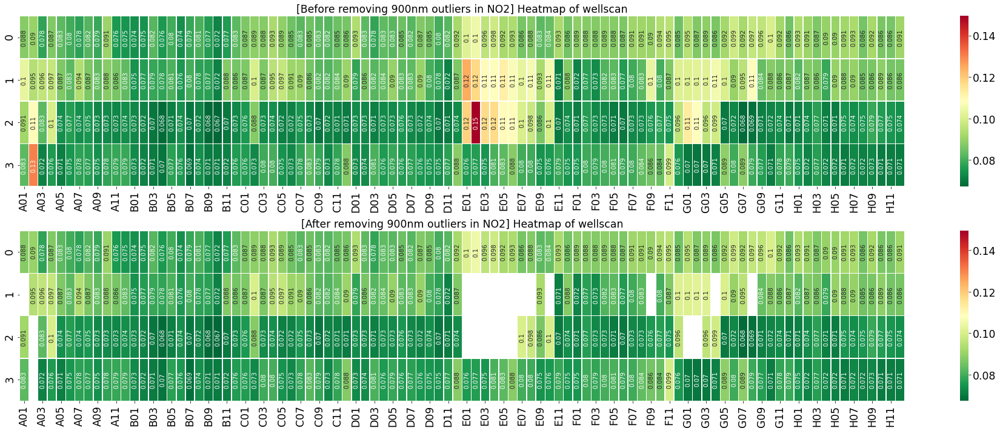

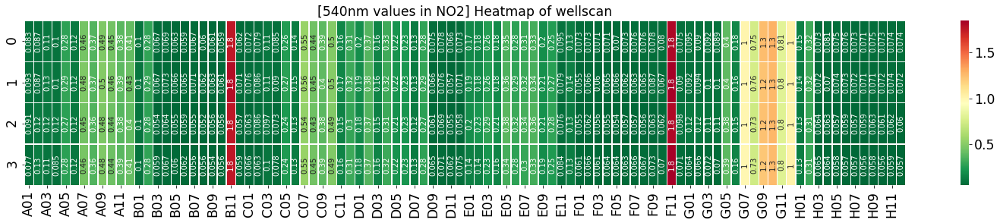

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


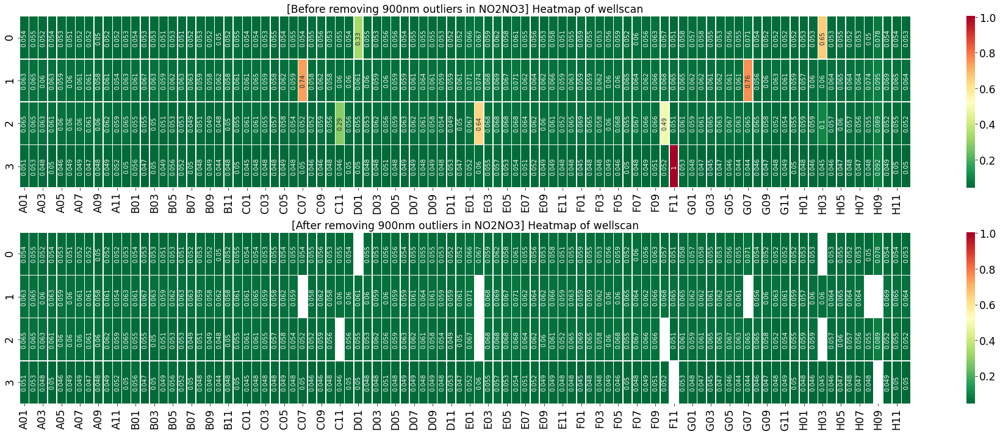

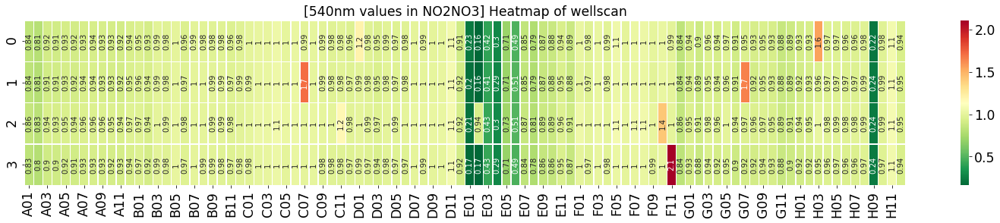

./240907_Griess/sample_metadata_RBW34_T2.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.08280
A02    0.08730
A03    0.11545
A04    0.10180
A05    0.27910
        ...   
H08    0.06500
H09    0.06680
H10    0.06655
H11    0.06765
H12    0.06590
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.83885
A02    0.80795
A03    0.91435
A04    0.91070
A05    0.92760
        ...   
H08    0.97660
H09    0.23170
H10    0.98570
H11    1.07235
H12    0.94495
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.018919
A02    0.020923
A03    0.033469
A04    0.027383
A05    0.106763
         ...   
H08    0.010996
H09    0.011797
H10    0.011686
H11    0.012175
H12    0.011397
Name: NO2_mM, Length: 96, dtype: float64
A01    0.614748
A02    0.587210
A03    0.682424
A04    0.679

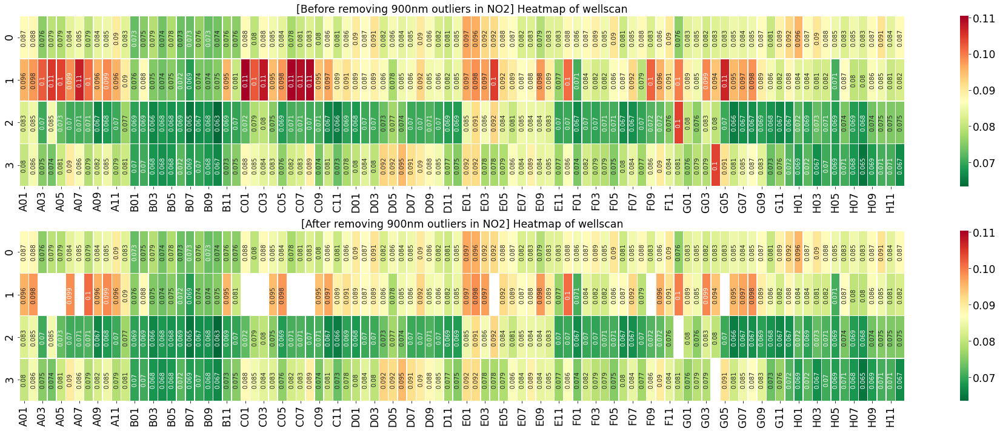

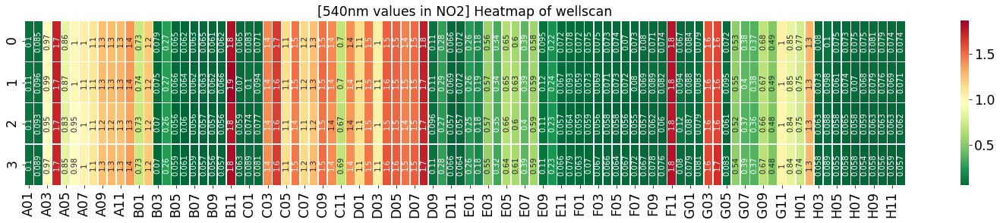

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


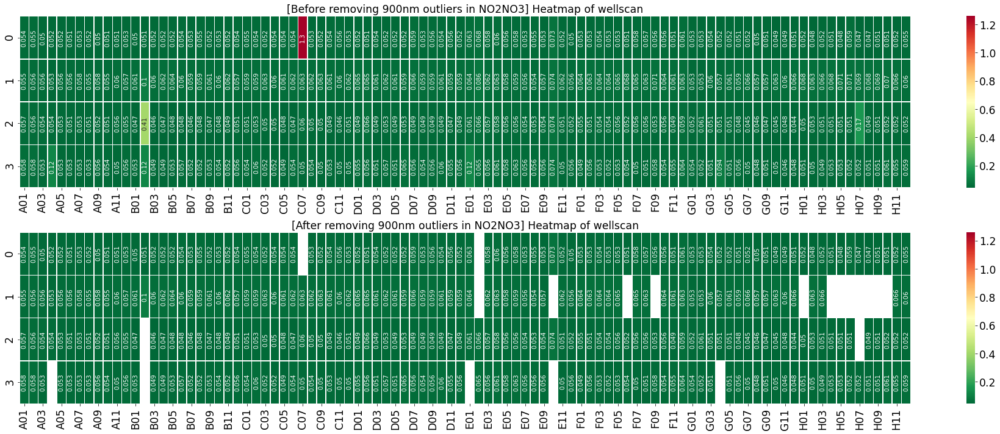

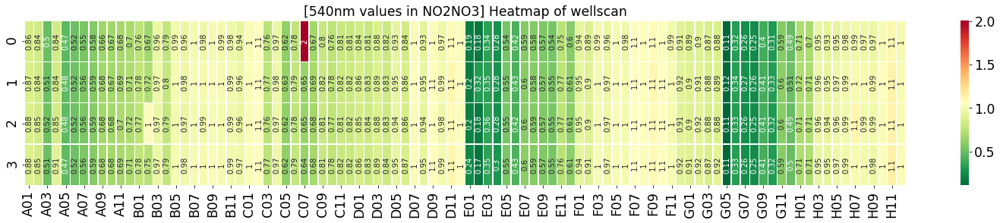

./240907_Griess/sample_metadata_RBW34_T3.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.10340
A02    0.09075
A03    0.96970
A04    1.72850
A05    0.85190
        ...   
H08    0.06385
H09    0.07120
H10    0.06955
H11    0.06605
H12    0.06665
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.87185
A02    0.84250
A03    0.50960
A04    0.84280
A05    0.47550
        ...   
H08    0.99180
H09    0.98020
H10    1.03320
H11    1.13390
H12    1.01915
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.028096
A02    0.022459
A03    0.423043
A04    0.784774
A05    0.368263
         ...   
H08    0.010485
H09    0.013755
H10    0.013021
H11    0.011463
H12    0.011730
Name: NO2_mM, Length: 96, dtype: float64
A01    0.644259
A02    0.618007
A03    0.325900
A04    0.618

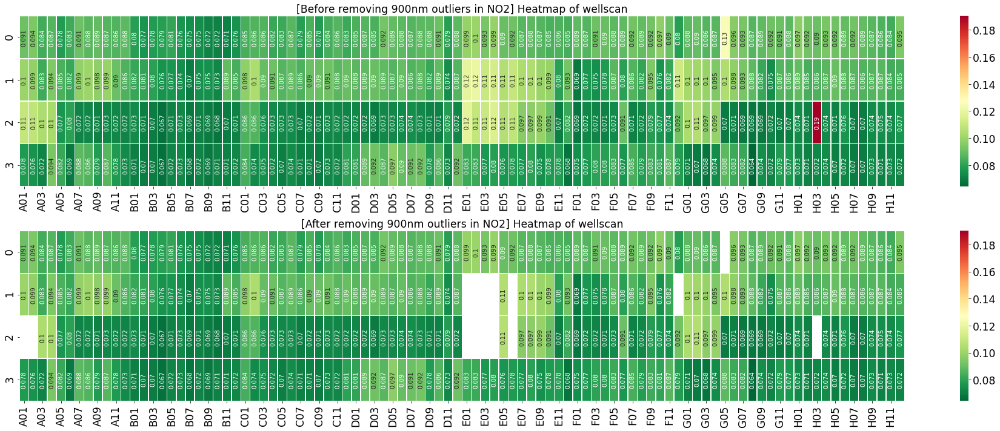

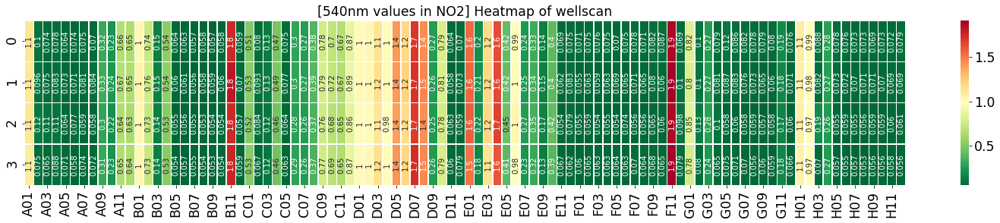

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


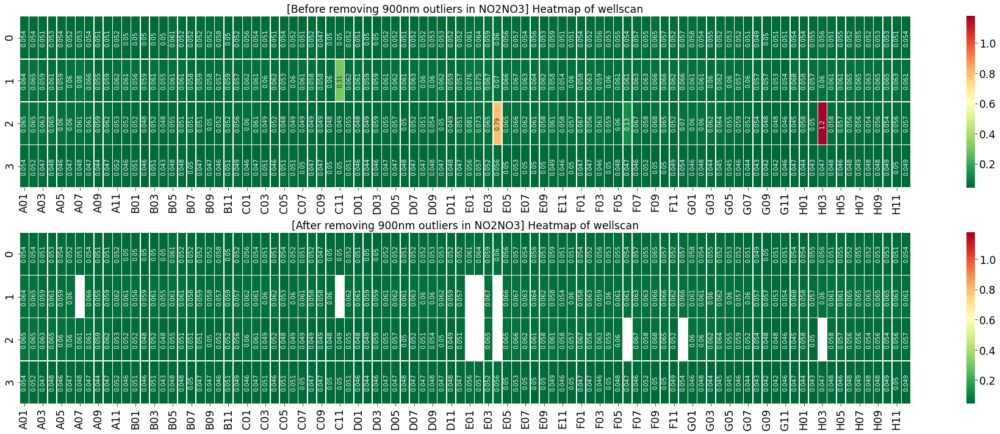

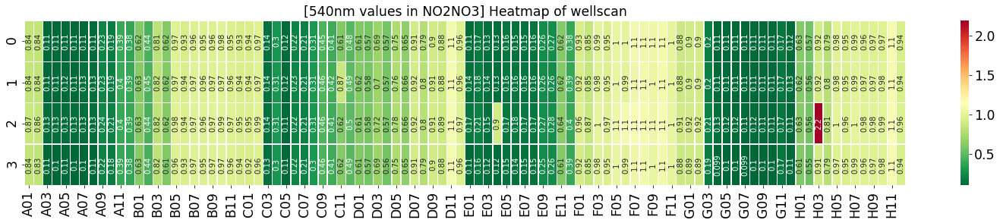

./240907_Griess/sample_metadata_RBW34_T4.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    1.11680
A02    0.09640
A03    0.07460
A04    0.08540
A05    0.06765
        ...   
H08    0.06345
H09    0.06440
H10    0.06490
H11    0.06485
H12    0.06505
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.83650
A02    0.83720
A03    0.11125
A04    0.10950
A05    0.11645
        ...   
H08    0.96855
H09    0.97030
H10    0.97945
H11    1.08605
H12    0.93740
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.491951
A02    0.024977
A03    0.015268
A04    0.020077
A05    0.012175
         ...   
H08    0.010307
H09    0.010729
H10    0.010952
H11    0.010930
H12    0.011019
Name: NO2_mM, Length: 96, dtype: float64
A01    0.612651
A02    0.613275
A03    0.000000
A04    0.000

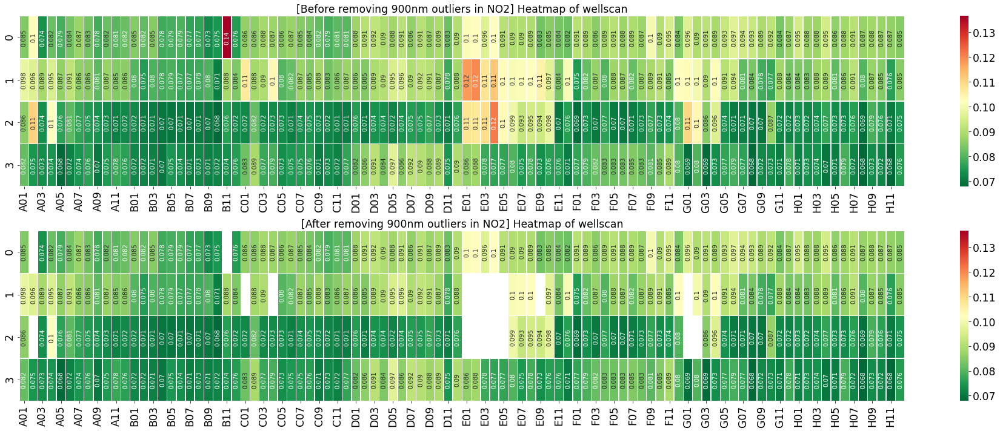

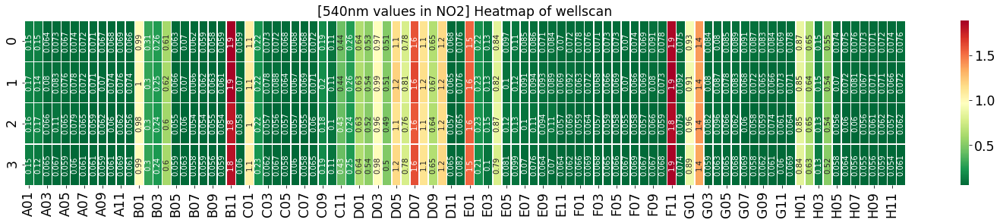

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


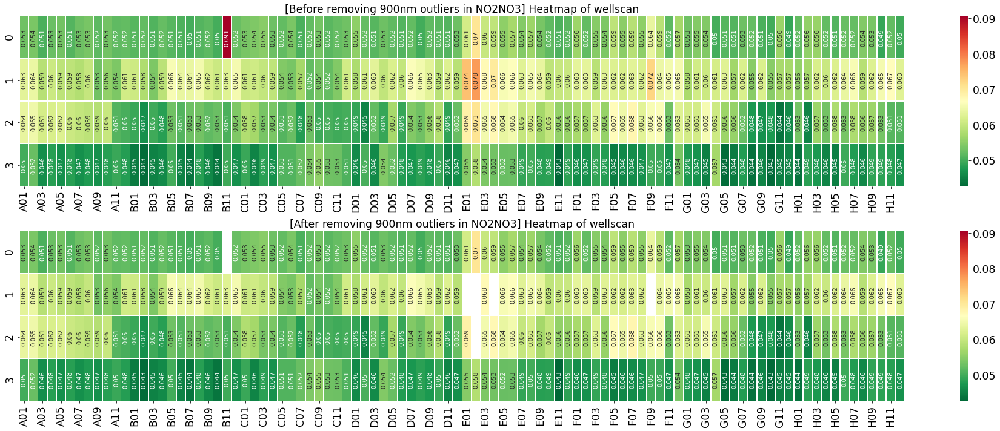

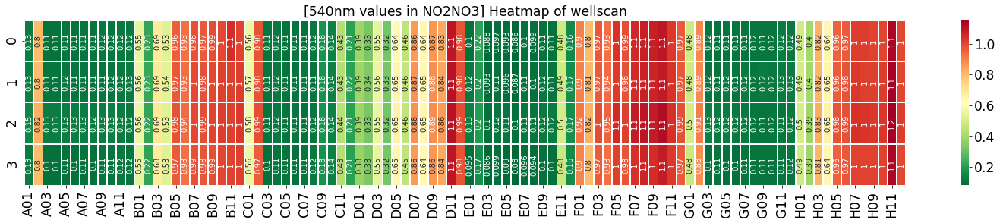

./240907_Griess/sample_metadata_RBW34_T5.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.15660
A02    0.13235
A03    0.06550
A04    0.07795
A05    0.06605
        ...   
H08    0.06150
H09    0.06615
H10    0.06610
H11    0.06165
H12    0.06705
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.12940
A02    0.80255
A03    0.10990
A04    0.10855
A05    0.11300
        ...   
H08    1.01870
H09    1.01335
H10    1.01560
H11    1.14120
H12    1.00330
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.051842
A02    0.041010
A03    0.011219
A04    0.016759
A05    0.011463
         ...   
H08    0.009906
H09    0.011508
H10    0.011486
H11    0.009906
H12    0.011908
Name: NO2_mM, Length: 96, dtype: float64
A01    0.004081
A02    0.582407
A03    0.000000
A04    0.000

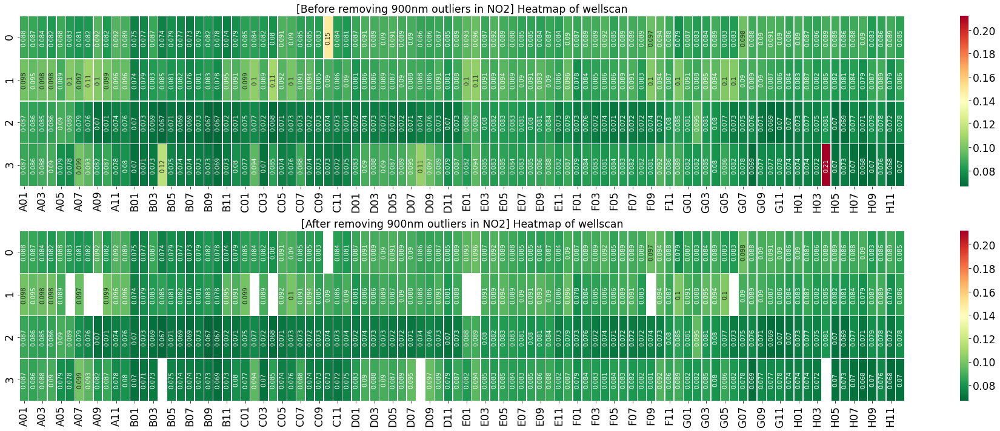

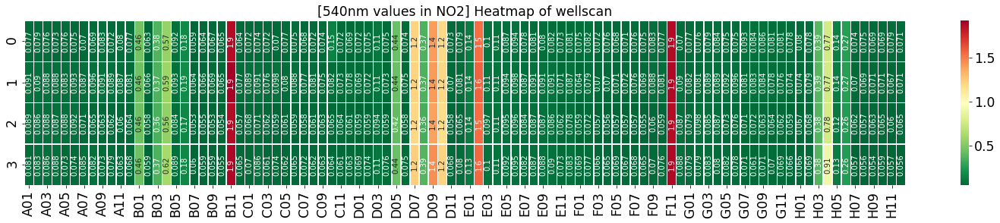

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


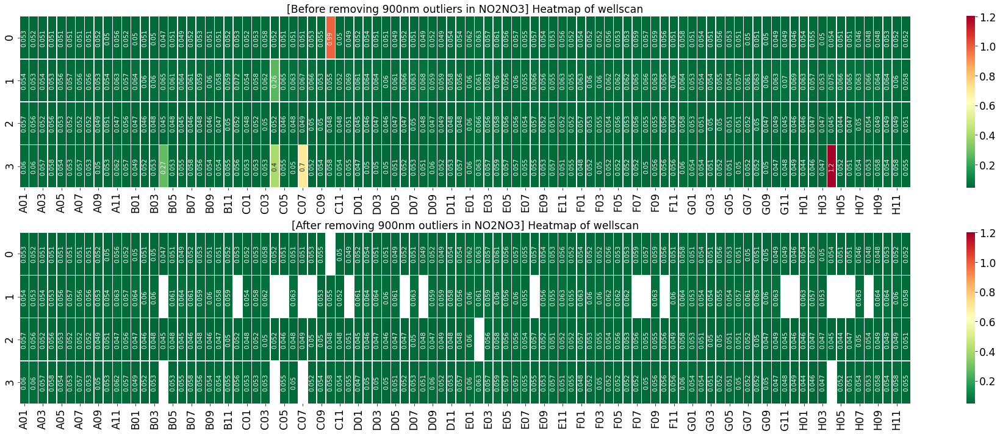

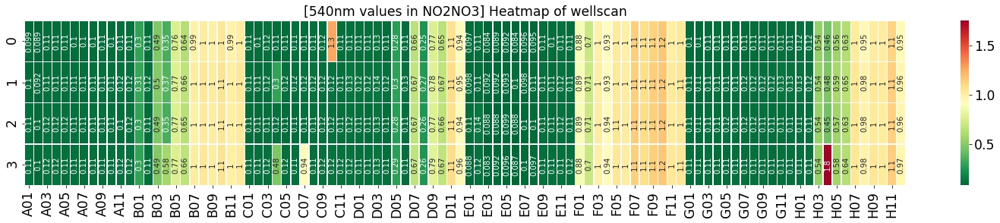

./240907_Griess/sample_metadata_RBW34_T6.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.08480
A02    0.08460
A03    0.08720
A04    0.08730
A05    0.07955
        ...   
H08    0.06295
H09    0.06580
H10    0.06690
H11    0.06340
H12    0.06780
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.10655
A02    0.09610
A03    0.11405
A04    0.11320
A05    0.11310
        ...   
H08    0.97930
H09    1.03520
H10    1.02555
H11    1.13535
H12    0.96130
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.019809
A02    0.019720
A03    0.020878
A04    0.020923
A05    0.017472
         ...   
H08    0.010084
H09    0.011352
H10    0.011842
H11    0.010284
H12    0.012242
Name: NO2_mM, Length: 96, dtype: float64
A01    0.000000
A02    0.000000
A03    0.000000
A04    0.000

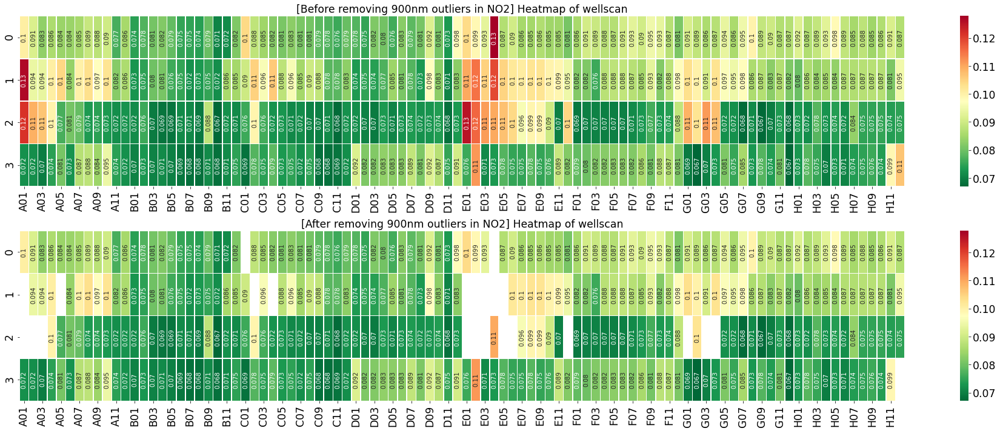

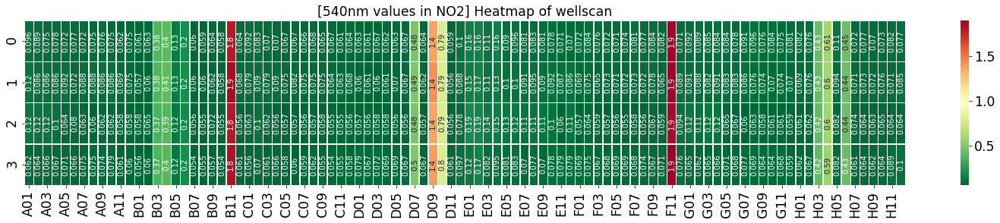

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


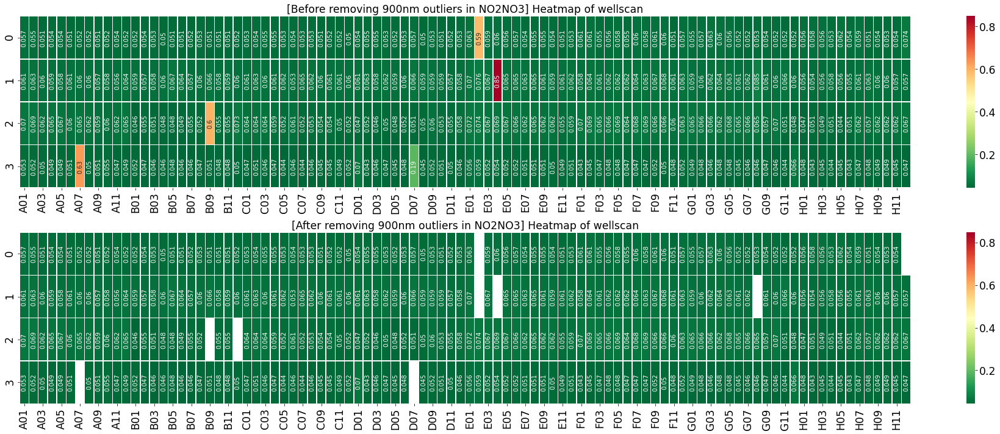

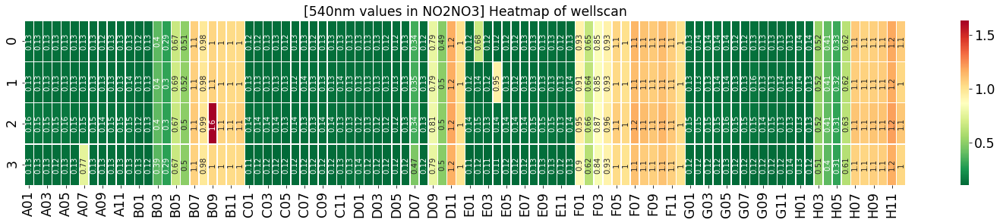

./240907_Griess/sample_metadata_RBW34_T7.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.07900
A02    0.08570
A03    0.07530
A04    0.08230
A05    0.07110
        ...   
H08    0.06855
H09    0.06635
H10    0.06905
H11    0.07660
H12    0.07680
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.13200
A02    0.13125
A03    0.13160
A04    0.13110
A05    0.13330
        ...   
H08    1.05915
H09    1.06845
H10    1.08230
H11    1.17765
H12    1.04700
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.017227
A02    0.020210
A03    0.015580
A04    0.018696
A05    0.013710
         ...   
H08    0.012576
H09    0.011597
H10    0.012798
H11    0.016158
H12    0.016247
Name: NO2_mM, Length: 96, dtype: float64
A01    0.006242
A02    0.005619
A03    0.005910
A04    0.005

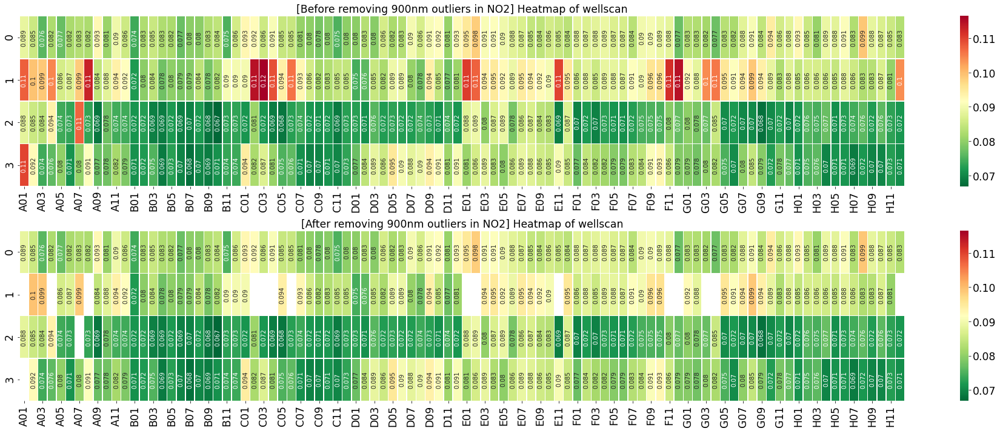

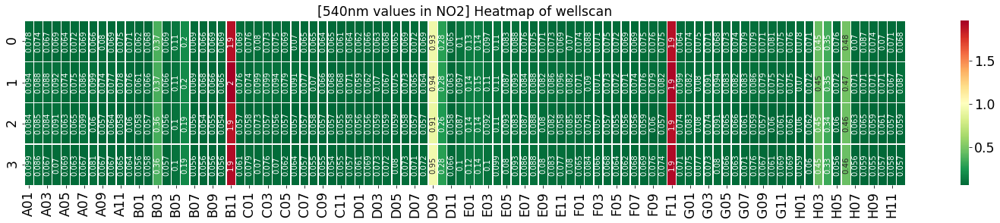

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


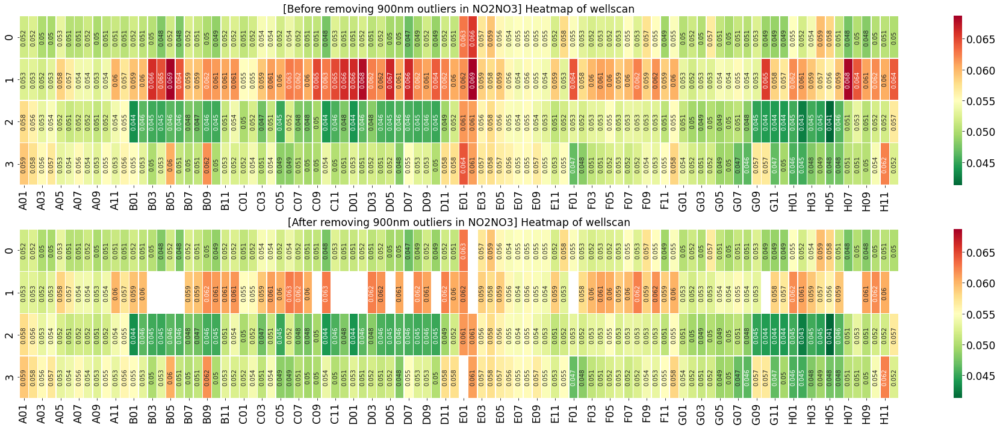

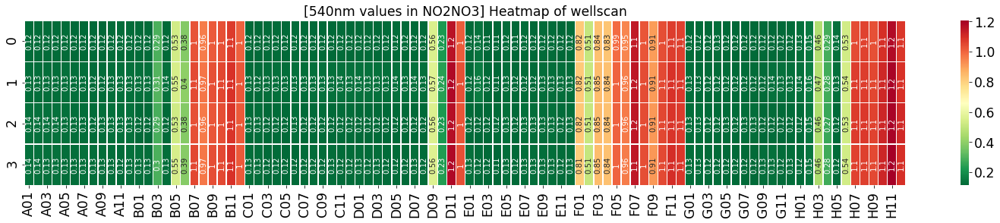

./240907_Griess/sample_metadata_RBW34_T8.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.08105
A02    0.08550
A03    0.07545
A04    0.07000
A05    0.06615
        ...   
H08    0.06800
H09    0.06495
H10    0.06565
H11    0.06275
H12    0.05870
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.13165
A02    0.13180
A03    0.12900
A04    0.13085
A05    0.12860
        ...   
H08    1.06970
H09    1.05245
H10    1.11770
H11    1.19605
H12    1.09870
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.018140
A02    0.020121
A03    0.015647
A04    0.013221
A05    0.011508
         ...   
H08    0.012331
H09    0.010974
H10    0.011285
H11    0.009995
H12    0.009906
Name: NO2_mM, Length: 96, dtype: float64
A01    0.005951
A02    0.006076
A03    0.003749
A04    0.005

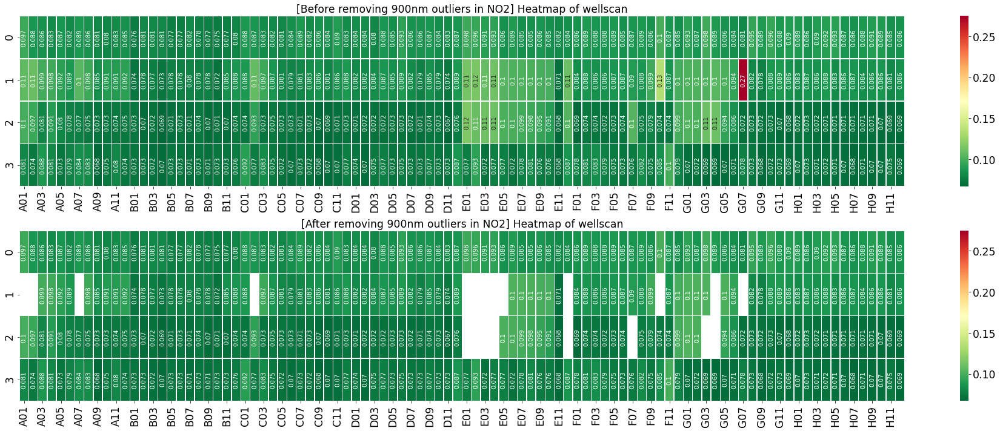

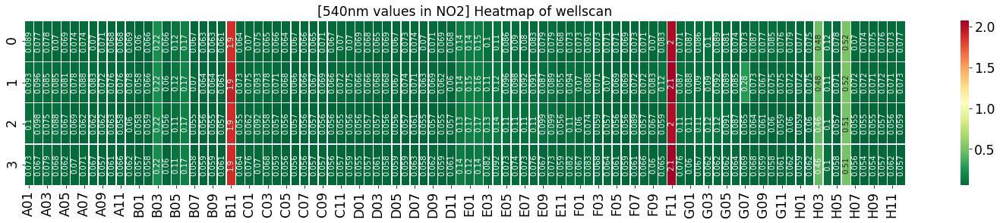

-----------------------
Check wellscan for outlier removal in NO2NO3
returns true for elements more than 1 interquartile ranges above the upper quartile


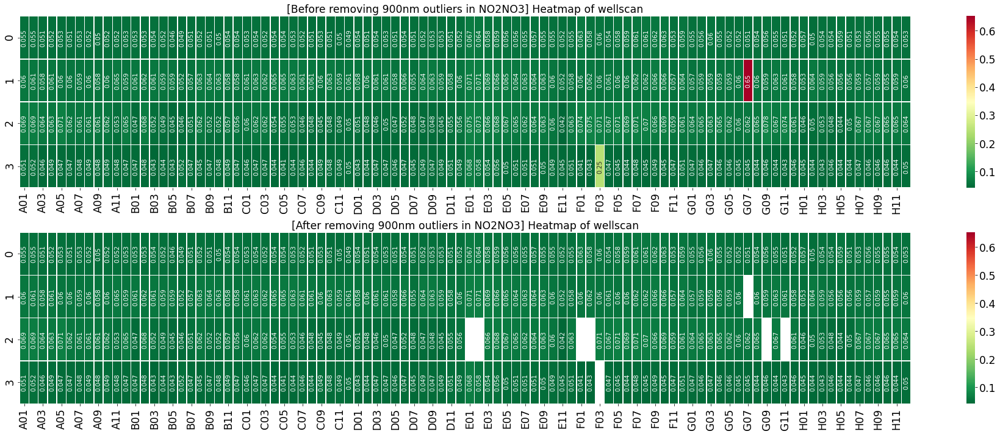

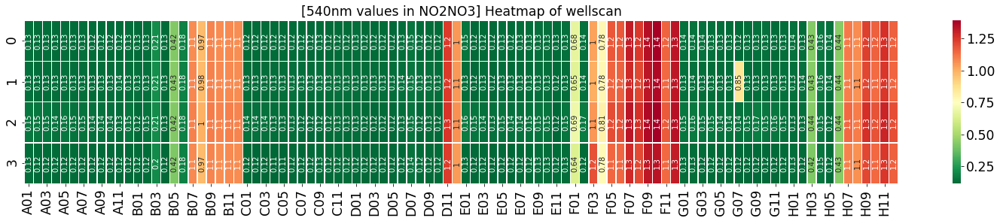

./240907_Griess/sample_metadata_RBW34_T9.csv
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.08870
A02    0.07740
A03    0.07855
A04    0.07740
A05    0.06765
        ...   
H08    0.06325
H09    0.06325
H10    0.06455
H11    0.06635
H12    0.06585
Name: NO2_OD540, Length: 96, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.13225
A02    0.13030
A03    0.12965
A04    0.12625
A05    0.13080
        ...   
H08    1.06900
H09    1.22320
H10    1.15200
H11    1.25725
H12    1.15875
Name: NO2NO3_OD540, Length: 96, dtype: float64
Subtracted blank value
Calculated NO2, NO3 concentrations
A01    0.021546
A02    0.016515
A03    0.017027
A04    0.016515
A05    0.012175
         ...   
H08    0.010218
H09    0.010218
H10    0.010796
H11    0.011597
H12    0.011374
Name: NO2_mM, Length: 96, dtype: float64
A01    0.006450
A02    0.004829
A03    0.004289
A04    0.001

In [54]:
# Loop through sample names
for i in l_soil:
    for j in l_timepoint:
        sample_name = i+"_"+j
        print(sample_name)
        AW_plate1_2_T0_meta_fn = "./240907_Griess/sample_metadata_"+sample_name+".csv"
        print(AW_plate1_2_T0_meta_fn)
        AW_plate1_2_T0_no2_fn = None
        print(AW_plate1_2_T0_no2_fn)
        AW_plate1_2_T0_no2_540_fn = glob.glob("./240907_Griess/*"+sample_name+"_*NO2_SCAN_540*")[0]
        print(AW_plate1_2_T0_no2_540_fn)
        AW_plate1_2_T0_no2_900_fn = glob.glob("./240907_Griess/*"+sample_name+"_*NO2_SCAN_900*")[0]
        print(AW_plate1_2_T0_no2_900_fn)
        AW_plate1_2_T0_no2no3_fn = None
        print(AW_plate1_2_T0_no2no3_fn)
        AW_plate1_2_T0_no2no3_540_fn = glob.glob("./240907_Griess/*"+sample_name+"_*NO2NO3_SCAN_540*")[0]
        print(AW_plate1_2_T0_no2no3_540_fn)
        AW_plate1_2_T0_no2no3_900_fn = glob.glob("./240907_Griess/*"+sample_name+"_*NO2NO3_SCAN_900*")[0]
        print(AW_plate1_2_T0_no2no3_900_fn)

        gr.get_concentration_xlsx(excel_output = "./240907_Griess/Output/240907_Griess_"+sample_name+".xlsx",
                                  no2_blank = no2_blank, no2no3_blank = no2no3_blank, g_fit = g_fit, v_fit = no3_fit, 
                             meta_fn = AW_plate1_2_T0_meta_fn, no2_fn=None, no2_540_fn = AW_plate1_2_T0_no2_540_fn, no2_900_fn = AW_plate1_2_T0_no2_900_fn, no2no3_fn=None, no2no3_540_fn=AW_plate1_2_T0_no2no3_540_fn, no2no3_900_fn=AW_plate1_2_T0_no2no3_900_fn)
        
        print("--------------------------------------------------------------------------------------------------------------")

        